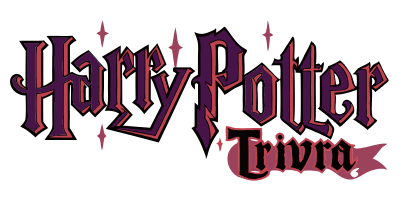

<div style="background-color: #f0e6f7; padding: 10px;">
    <h2 style="text-align:center; color:purple;">Harry Potter Trivia Game</h2>
    <h3 style="text-align:center; color:purple;">Data preparation and EDA</h3>
</div>

## 1. Introduction

The goal of this project is to create an engaging Harry Potter Trivia game. This notebook focuses on the foundational step: cleaning and exploring the public dataset that will power the game's content.

The Harry Potter Trivia game will be built using a public dataset of trivia questions from Huggingface. The dataset was downloaded using the `download_data.py` script, the train and test split were combined and stored as a single csv file from [saracandu/harry-potter-trivia-human](https://huggingface.co/datasets/saracandu/harry-potter-trivia-human/tree/main) on January 25, 2025. 

The primary objective of *this notebook* is to clean the dataset and perform exploratory data analysis (EDA) to understand its characteristics and prepare it for potential downstream use (e.g., game logic, model training) and create a clean csv file that can be used in the Phase-1 version of the CLI-MVP of the game.

#### Workflow Summary

The main stages covered in this notebook include:
1. **Data Preparation:** Cleaning and preparing the raw trivia data (handling nulls, duplicates, types, feature selection).
2. **Basic Exploratory Data Analysis (EDA):** Initial analysis and visualization of the questions and answers in the cleaned dataset.
3. **Keyword Generation:** Tokenizing question and answer text using lemmatization to create keyword features.
3. **In-depth EDA:** Grandular analysis and visualization of the cleaned dataset with the generated keywords.
4. **Finalize dataset for CLI-MVP:** Create a clean dataset csv file that can be used in the phase-1, CLI-MVP version of the game.  Provide a basis for expanding the trivia question and answer dataset in future development phases.


## Table of Contents

1. [Introduction](#1-Introduction)<br>
2. [Setup and imports](#2-Setup-and-imports)<br>
3. [Data preparation](#3-data-preparation)<br>
    **PART-1**: Basic EDA<br>
4. [Basic Exploratory Data Analysis (EDA)](#4-Basic-EDA-of-the-cleaned-dataset)<br>
    4.1. [Overview](#41-Overview)<br>
    4.2. [Answer lengths](#42-Answer-lengths)<br>
    4.3. [Question lengths](#43-Questions-lengths)<br>
    4.4. [Question and answer correlations](#44-Question-and-answer-correlation)<br>
    **PART-2**: Feature engineering<br>
5. [Keyword feature engineering](#5-Keyword-feature-engineering) <br>
    **PART-3**: In-depth EDA with keywords and N-grams <br>
6. [EDA based on keywords](#6-EDA-based-on-keywords)<br>
    6.1. [Unique keyword frequency](#61-unique-keyword-frequency) <br>
    6.2. [Factual recall questions](#62-factual-recall-questions)<br>
    6.3. [Questions that do not have factual recall keywords](#63-questions-that-do-not-have-factual-recall-keywords)<br>
    6.4. [Common N-grams in the dataset](#64-common-n-grams-in-the-dataset)
7. [Extending the dataset with new question categorization columns](#7-Extending-the-dataset-with-new-question-categorization-columns)<br>
8. [Summary](#8-Summary)<br>
9. [Key findings](#9-Key-findings)<br>
    **PART-4**: Finalizing dataset for CLI-MVP<br>    
10. [Data dictionary](#10-Data-dictionary)<br>
11. [Next steps](#11-Next-steps)<br>

## 2. Setup and imports

Import the necessary external packages.

In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import re
from scipy.stats import shapiro
from collections import Counter, OrderedDict
from typing import Union

from nltk import pos_tag
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer

Import the internal environment configuration file.

In [2]:
# Import the project environment configurations and load them.
import dotenv
dotenv.load_dotenv()  

True

Finally, import the custom utility module to manage file paths for this project.

In [3]:
from utils import utils_paths as up
import eda_scripts as eda
# Initialize counter to update figure number automatically for the visuals:
figure_count = 0

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>

## 3. Data preparation

In [4]:
# convert csv file to dataframe
project_root = up.find_project_root()
rawcsv_path = project_root / "data" / "original_dataset_DONT_TOUCH"/"harry_potter_trivia_questions_HFdataset.csv"
raw_df = pd.read_csv(rawcsv_path)
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1279 entries, 0 to 1278
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   question  1279 non-null   object
 1   answer    1279 non-null   object
 2   text      1279 non-null   object
dtypes: object(3)
memory usage: 30.1+ KB


There are 1279 rows and 3 columns. 

In [5]:
raw_df.sample(5)

,question,answer,text
573,"In 1876, which caretaker tried to make Peeves ...",Rancorous Carpe,"<s>[INST] In 1876, which caretaker tried to ma..."
812,What did Harry do to get him temporarily expel...,He chases away dementors,<s>[INST] What did Harry do to get him tempora...
948,What magical sport is popular in North America?,Quodpot,<s>[INST] What magical sport is popular in Nor...
456,What is Ron's favorite Quidditch team?,Chudley Cannons,<s>[INST] What is Ron's favorite Quidditch tea...
343,Which Quidditch players fend off the Bludgers?,The Beaters,<s>[INST] Which Quidditch players fend off the...


We have the question and answers in the first two columns. Let's look at the `text` columnn data for the first row:

In [6]:
# Look at the contents of the first row, third column record (i.e. text column) without being clipped.
print(raw_df.iloc[0,2])  

<s>[INST] What are the three European wizarding schools that participate in the Triwizard Tournament? [/INST] Hogwarts, Beauxbatons, and Durmstrang. </s>


The third column is used for NLP training and we don't need it for this game. So we can get rid of it.

In [7]:
# Drop the `text` column:
raw_df = raw_df.drop(columns=['text'])
print(raw_df.columns)

Index(['question', 'answer'], dtype='object')


In [8]:
# lets check for nulls, just to be sure.
raw_df.isna().sum()

question    0
answer      0
dtype: int64

In [9]:
# check for duplicates
raw_df.duplicated().sum()

np.int64(194)

Let's take a quick look at the duplicated row counts and also make sure that they are duplicates.

In [10]:
# Find duplicates based on all columns
duplicates = raw_df[raw_df.duplicated(keep=False)]

# Count occurrences of each duplicate row
duplicate_counts = duplicates.groupby(duplicates.columns.tolist()).size().reset_index(name='Count')

# Display the counts of each duplicate
print(duplicate_counts)

                                             question           answer  Count
0                       A Firebolt is a type of what?            Broom      5
1                         A Nimbus is a type of what?            Broom      5
2   According to Madam Hooch, which of the followi...        Long hair      5
3   Before Dumbledore, who was Headmaster of Hogwa...   Armando Dippet      2
4        Catching what object ends a Quidditch match?    Golden Snitch      5
..                                                ...              ...    ...
64  Who previously held Snape's post as Potions Ma...  Horace Slughorn      2
65                  Who previously held Snape's post?  Horace Slughorn      2
66  Who was the first witch or wizard to hatch a b...   Herpo the Foul      2
67        Why would you need to switch brooms midair?    Broom failure      5
68  You wouldn't know anything about this. Name a ...     Using polish      5

[69 rows x 3 columns]


If we sort the rows then the duplicates will show up together. 

In [11]:
# Sort `raw_df' by the `question` column
raw_sorted = raw_df.sort_values(by='question')
raw_sorted

,question,answer
28,"""Lemon Drop"" is the password to whose office?",Dumbledore
1009,A Firebolt is a type of what?,Broom
116,A Firebolt is a type of what?,Broom
1139,A Firebolt is a type of what?,Broom
1074,A Firebolt is a type of what?,Broom
...,...,...
1065,You wouldn't know anything about this. Name a ...,Using polish
1091,You wouldn't know anything about this. Name a ...,Using polish
3,You wouldn't know anything about this. Name a ...,Using polish
461,You wouldn't know anything about this. Name a ...,Using polish


In [12]:
trivia_df = raw_df.drop_duplicates(keep='first')

In [13]:
trivia_df.shape

(1085, 2)

After dropping the duplicates, we have 1085 unique questions left.

Now let's convert the `question` and `answer` columns to `str` for clarity, type safety, and make sure the `str` methods are available for them.

In [14]:
# convert columns from 'object` to `str`
trivia_df = trivia_df.astype({
    'question': 'string',
    'answer': 'string'})

print("\nData types after conversion:")
trivia_df.info()


Data types after conversion:
<class 'pandas.core.frame.DataFrame'>
Index: 1085 entries, 0 to 1278
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   question  1085 non-null   string
 1   answer    1085 non-null   string
dtypes: string(2)
memory usage: 25.4 KB


In [15]:
trivia_df.head()

,question,answer
0,What are the three European wizarding schools ...,"Hogwarts, Beauxbatons, and Durmstrang."
1,When was Hogwarts founded?,10th century
2,What is a Wronski Feint?,Pretending to dive for the Snitch
3,You wouldn't know anything about this. Name a ...,Using polish
4,Harry first took the Knight Bus in The Prisone...,14 sickles.


---

#### 💾 Checkpoint 1: saving clean dataset
<details>
<summary> Click here for checkpoint details and <b>warning!</b> </summary>

The DataFrame is now cleaned and ready for EDA. Saving the current state.
<br>
> **⚠️ Caution: Manual Intervention Required for Saving Files**
>
> Please be aware that the `save_dataframe_to_csv` utility is designed to prevent accidental data loss. It **does not automatically overwrite** previously saved files.
>
> If you run a cell that calls this function and the output file (based on `filename_base`, `version`, and `subfolder`) already exists, the save operation will be skipped. You will see a message indicating this.
>
> **To save your latest data, you must manually intervene by either:**
> 1.  Deleting the older version of the CSV file from the file system.
> 2.  Modifying the `version` argument (or `filename_base`) in your function call to create a new, unique filename.

The following code saves the cleaned DataFrame to <code>data/project_datasets/</code> based on the selecte saved arguments.
</div>
</details>

In [16]:
# Using utils.paths.py module -> prevents overwritting csv file unless manually done.

# Save arguments
dataframe_to_save = trivia_df
name_for_csvfile = 'clean_trivia_dataset'
csv_version = 'v0'
csv_subfolder = 'project_datasets'

# Save csv  file with custom functions and defined save arguments
up.save_dataframe_to_csv(dataframe_to_save, name_for_csvfile, csv_version, csv_subfolder)

File already exists at: data/project_datasets/clean_trivia_dataset_v0.csv. Skipping save.


<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>

<div align="center" style="background-color: #f0e6f7; padding: 10px;">
    <span style="color:purple; font-size:32px;">Part-1: Basic Exploratory Data Analysis (EDA)</span>
</div>

## 4. Basic EDA of the cleaned dataset


    - Basic descriptive statistics 
    - Question and Answer length distribution & Textual analysis (word count, average number of words per sentence)
    - Question type classification (Yes/No, open-ended, factual, opinon-based, or mixed?)
    - Answer completeness (are short answers correct or incomplete? any missing answers?)
    - Question and answer correlations (Length of answers by question length / type, answer relevance)
    - Topic modelling and keyword analysis (unique words / vocabulary size, frequent words) -> keyword extraction / Latent Dirichlet Allocation (LDA)?
    - Context analysis (is from all HP corpus or just certain books?)  

### 4.1. Overview

In [17]:
# Let's look at the lengths of questions:

# extract the length of each question and answer using the helper function from the eda_scripts module
question_lengths = eda.get_clean_word_counts(trivia_df, "question")
answer_lengths = eda.get_clean_word_counts(trivia_df, "answer")

length_analysis = pd.DataFrame({"question": question_lengths, "answer": answer_lengths}).describe()
print(length_analysis)

          question       answer
count  1085.000000  1085.000000
mean      9.851613     2.659908
std       4.326515     2.657494
min       3.000000     1.000000
25%       7.000000     1.000000
50%       9.000000     2.000000
75%      12.000000     3.000000
max      31.000000    25.000000


The answers are generally shorter then the questions. Most answers are about 1 to 3 words while most questoins are about 9 words. 

We can also look at the distributions visually.

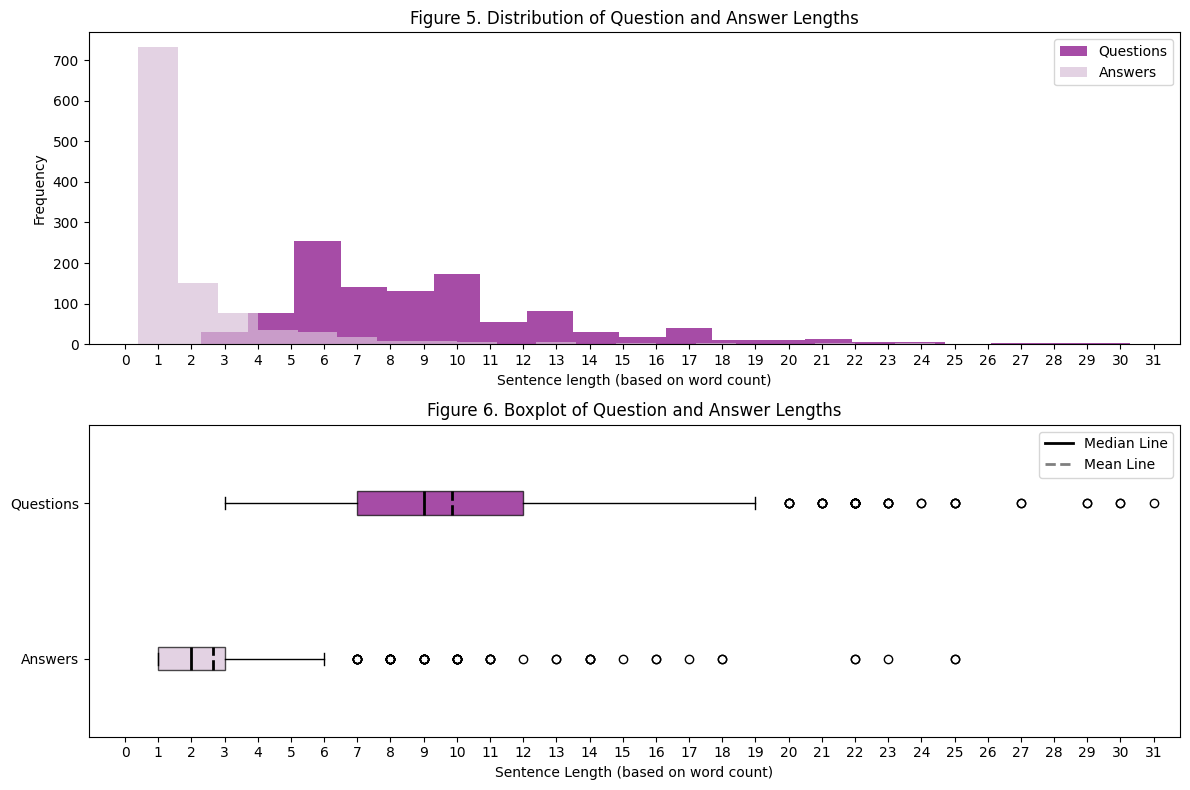

In [71]:
# let's plot the distribution of lengths of questions and answers

# A 1x2 grid of plots
fig, axs = plt.subplots(2,1,figsize=(12, 8))

# PLOT 1: Plot a histogram of the distribution of question lengths
# update figure_count for visual:
figure_count += 1
axs[0].hist(question_lengths, bins=20, color='purple', alpha=0.7,align='left')
# Plot the distribution of answer lengths
axs[0].hist(answer_lengths, bins=20, color='thistle', alpha=0.7,align='left')
# Formatting
axs[0].set_title(f"Figure {figure_count}. Distribution of Question and Answer Lengths")
axs[0].set_xlabel("Sentence length (based on word count)")
axs[0].set_ylabel("Frequency")
axs[0].legend(["Questions", "Answers"])

# PLOT 2: Boxplot for question and answer lengths
# update figure_count for visual:
figure_count += 1
box = axs[1].boxplot([ answer_lengths, question_lengths], vert=False, patch_artist=True,
               tick_labels=["Answers", "Questions"],
               boxprops=dict(color="black"),  # Box border color
               medianprops=dict(color="black", linewidth=2),  # Median line in black
               meanline=True, showmeans=True, meanprops=dict(color="black", linewidth=2)
               )
# Fill colors for boxes
colors = ["thistle", "purple"]
for patch, color in zip(box["boxes"], colors):
    patch.set(facecolor=color, alpha=0.7)  # Set fill color
axs[1].set_title(f"Figure {figure_count}. Boxplot of Question and Answer Lengths")
axs[1].set_xlabel("Sentence Length (based on word count)")
# Create legend handles
legend_elements = [
    Line2D([0], [0], color="black", linewidth=2, label="Median Line"),
    Line2D([0], [0], color="black", linewidth=2, linestyle="--", label="Mean Line", alpha=0.5)
]
# Add legend to boxplot
axs[1].legend(handles=legend_elements, loc="upper right")

# Ensure both plots have the same x-axis range
axs[1].set_xlim(axs[0].get_xlim())
# Set x-axis ticks to go up in unit steps
axs[0].set_xticks(range(int(min(question_lengths & answer_lengths)), int(max(question_lengths | answer_lengths)) + 1))
axs[1].set_xticks(range(int(min(question_lengths & answer_lengths)), int(max(question_lengths | answer_lengths)) + 1))

plt.tight_layout()
plt.show()

From the plot above:
- Both questions and answers have longer sentences as outliers, perhaps they can be made more concise / clearer?
- The questions looks like a right-skewed normal distribution
- Most questions are ~12 words or less (75% percentile)
- Most questions fall between 7 and 12 words (inter-quartile range), with a mean of 9 words.
- The answers is also a very right-skewed distribution with a rapid decay.
- Most answers are ~3 words or less (75% percentile)
- One word answers are the most common.
- So the answers are generally short words that should make answer checking simpler.

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>

### 4.2. Answer lengths

An analysis of answer lengths within the dataset helps set expectations for complexity in player response within the trivia game. The distribution of word counts indicates whether typical player input is likely to be short (mirroring the dataset's concentration of 1-3 word answers) or will sometimes include much longer responses (reflecting the dataset's long tail).Establishing a clear definition for 'short' and 'long' answers, based on the dataset's statistical properties, enables a structured analysis. 

 The descriptive statistics in [section 4.1](#41-overview) show 75% of answers have 3 words or fewer (Q3 is 3 words) and an interquartile range (IQR) of 2 words. The outlier threshold (Q3 + 1.5*IQR = 6) provides a suitable cutoff such that: 
- *answers qualify as "short" with 6 or fewer words*, 
- *answers qualify as "long" with 7 or more words*.

Beyond length, examining the diversity in answers is also crucial. This can influences gameplay engagement and the requirements for the answer-checking system. 
- A diverse answer set indicates it covers a good range of the Harry Potter universe (characters, spells, places etc.) and less  repetition which will make the in-game experience more immersive and engaging. 
- Along with length, the type and obscurity of the answer can help determine the range of difficulty within the dataset.
- High diversity could also mean that the same thing is being said in different ways. For example a question with the answer "Professor Albus Dumbledore" could have synonym like answers such as "Albus", "Albus Dumbledore", "the headmaster" etc. This would inform the design considerations for semantic-similarity analysis in later project phases.
- Ultimately, this analysis of answer characteristics contributes to a fuller understanding of the dataset, helping confirm its suitability for the MVP by verifying content variety and informing the design scope for answer evaluation.

>📝 **Note**: 
> 
>Understanding the dataset's answer diversity by analyzing keyword uniqueness and semantic similarity (e.g., 'Albus' vs 'Dumbledore') is important for assessing content variety and refining the requirements for the player answer semantic comparison logic. This specific dataset analysis will be undertaken in Phase 2, synergistic with NER efforts, allowing the current phase to focus on the MVP's core game loop and initial answer evaluation setup.

This section analyzes answer characteristics, starting with a high-level look at word count frequencies ([section 4.2.1](#421-high-level-analysis-of-word-frequency-and-uniqueness)). Subsequently, it examines a basic measure of uniqueness, determined by counting distinct answer strings (value counts), within both short ([section 4.2.2](#422-short-answers)) and long ([section 4.2.3](#423-long-answers)) answer categories.

#### 4.2.1. High-level analysis of word frequency and uniqueness

In [ ]:
# Print a header for clarity:
print("Summary of answer length frequencies:")

# Frequency of answers based on word count
# In the resulting series: Index = Word Count, Value = Frequency (Number of answers with that word count)
word_count_freq = answer_lengths.value_counts().sort_index() # Sorted by index (=word count)

# Total number of answers:
total_answers = trivia_df.shape[0]

# Answer length binned by word-count: (1 to 3), (4 to 11), and (12+) 
count_1to3_wc = word_count_freq.loc[(word_count_freq.index >= 1) & (word_count_freq.index <= 3)].sum()
count_4to11_wc = word_count_freq.loc[(word_count_freq.index >= 4) & (word_count_freq.index <= 11)].sum()
count_12plus_wc = word_count_freq.loc[word_count_freq.index >= 12].sum()

# Percentage of each Answer word count bin
percentage_1to3_wc = (count_1to3_wc / total_answers) * 100
percentage_4to11_wc = (count_4to11_wc / total_answers) * 100
percentage_12plus_wc = (count_12plus_wc / total_answers) * 100

# Calculate the number of answers with a word count more than 3:
count_more_than_3 = word_count_freq.loc[word_count_freq.index > 3].sum()

# Display the results:
print(f'\nTotal number of answers analyzed: {total_answers}') 
print(f'\nThe number of answers with a word count more than 3: {count_more_than_3}') 

# Print calculated counts 
print(f'Count 1-3 words: {count_1to3_wc}')
print(f'Count 4-11 words: {count_4to11_wc}')
print(f'Count 12+ words: {count_12plus_wc}')

# Display percentages
print(f'\nPercentage of answers with word count between 1 and 3: {percentage_1to3_wc:.2f}%')
print(f'Percentage of answers with word count between 4 and 11: {percentage_4to11_wc:.2f}%')
print(f'Percentage of answers with word count 12 or more: {percentage_12plus_wc:.2f}%')

# Verify percentages add to ~100%
print(f'\nTotal Percentage (check): {percentage_1to3_wc + percentage_4to11_wc + percentage_12plus_wc:.2f}%')

print(f'\nIndividual word count frequencies in answers (truncated for counts > 9):\n\n{word_count_freq[word_count_freq>9]}')

Summary of answer length frequencies:

Total number of answers analyzed: 1085

The number of answers with a word count more than 3: 201
Count 1-3 words: 884
Count 4-11 words: 183
Count 12+ words: 18

Percentage of answers with word count between 1 and 3: 81.47%
Percentage of answers with word count between 4 and 11: 16.87%
Percentage of answers with word count 12 or more: 1.66%

Total Percentage (check): 100.00%

Individual word count frequencies in answers (truncated for counts > 9):

answer
1    370
2    362
3    152
4     78
5     34
6     30
8     11
Name: count, dtype: int64


**Observations:**
1. Majority of the answers are 1 to 3 words (81% of total answers).
2. The remaining answers mostly fall within 4 to 11 word counts (17% of total) with the rest with 12 or more words occuring only ~2%.

Majority (81%) of the answers are short (1 to 3 words). The interquaritile range is between 1 to 3 words. The distribution is right-skewed with a rapid decay. About 17% has answer lengths between 4 to 11 words while the remaining 2% have a word count of 12 or more. The maximum answer length is 25 words.
 - For analysis, answers with a word count of 6 (Q3 + 1.5* IQR) was used as cutoff for categorizing answers into short (wc <= 6) and long answers (wc > 6).
- The short anwerer are generally unique indicating there is good variety. The short answer will also simplify checking answers. 
   

#### 4.2.2. Short answers:

In [87]:
# Filter short answers
short_answers = trivia_df[answer_lengths <= 6]

# filter by word_counts
answer_n_wc = {n: trivia_df[answer_lengths == n] for n in [1, 2, 3]}

# Number of unique words for each word count occurence:
unique_answers = {n: answer_n_wc[n]['answer'].nunique() for n in range(1, 4)}

# Extract frequency occurence for answers with 1,2, and 3 words explicitly
total_by_wc = word_count_freq.loc[[1,2,3]]

# Display results
print(f"There are {short_answers.shape[0]} answers with six or less words; of those {total_by_wc.loc[1]} are one-word anwers\n")
# Number or unique words for one, two, and three word:
for i in range(1, 4):
    print(f"The number of unique {i}-word answers: {unique_answers[i]}, ({(unique_answers[i] / total_by_wc.loc[i]) * 100 :.0f}% of {i} word answers)")

# Display value counts of the one-word answers
print(f"\nOne word answers value counts:")
answer_n_wc[1]['answer'].value_counts()

There are 1026 answers with six or less words; of those 370 are one-word anwers

The number of unique 1-word answers: 310, (84% of 1 word answers)
The number of unique 2-word answers: 304, (84% of 2 word answers)
The number of unique 3-word answers: 141, (93% of 3 word answers)

One word answers value counts:


answer
Transfiguration    4
Fluffy             4
Five               3
Norbert            3
Depulso            3
                  ..
Bubotuber          1
Alohomora          1
Bezoar             1
Alchemy            1
Antidotes          1
Name: count, Length: 310, dtype: Int64

We can see that most of the short-word answers are unique and there is considerable variety in the answers. We would need to look at the answers in-more depth the diversity in answers from Harry Potter context in the NER analysis.

####  4.2.3. Long answers

In [ ]:
# display the full content of all columns without truncation
pd.set_option('display.max_colwidth', None)

# Filter and display the long answers, threshold 
wc_threshold = 6
long_answers= trivia_df[answer_lengths > wc_threshold]

# Display results
print(f"There are {long_answers['answer'].count()} answers with a word count greater than {wc_threshold}\n\n")
print(long_answers['answer'].sample(10))

There are 59 answers with a word count greater than 6


1263                                              Arithmancy, Care of Magical Creatures, Divination, Muggle Studies, or the Study of Ancient Runes.
1160                                                                                     Cedric Diggory (unnamed in the movie, but not in the book)
310                                                            Professor Flitwick, Professor McGonagall, Hagrid, Cornelius Fudge and Madam Rosmerta
545                   “Mr. and Mrs. Dursley, of number four, Privet Drive, were proud to say that they were perfectly normal, thank you very much.”
48                                                                              Filius Flitwick remains the Charms professor throughout the series.
339                                         Tom Riddle’s Diary, Nagini, the giant ring, the Hufflepuff cup, Slytherin Locket, and Ravenclaw diadem.
1278                                                    

**Notes**:
- Some of the longest (including the most long) answers are lists.
- A few answers are just wordy.
- Others need to be long to give the full answer.

In [22]:
# Let's look at long answer outliers:
long_answers= trivia_df[answer_lengths >= 17]

# Display the number of unique words in the one-word answers and total number of one-word answers
print(f"The number of outlier long answers: {long_answers.shape[0]}\n",
      f"\n The outlier long answers are:\n\n{long_answers['answer']}")

The number of outlier long answers: 8
 
 The outlier long answers are:

346                                                                                      38. It was 36 (one less than last year), but then Mrs. Dursley bought him two new presents to make up for it.
458                                                                                                                                     6-2-4-4-2. (Bonus: This spells M-A-G-I-C on a phone's keypad.)
545                                                                      “Mr. and Mrs. Dursley, of number four, Privet Drive, were proud to say that they were perfectly normal, thank you very much.”
655                                                                                                  He uses the Patronus Charm in front of a Muggle (Dudley, and only because there were Dementors!).
715                                                                       In the book, the mummy trips on its wrappings. In the movi

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>

### 4.3. Questions lengths

>📝  **Notes**:
>1. Majority of the answers are short words (75% of words are 3 words or less). This would make checking answers for these questions relatively straight forward.
>2. There are 179 answers that are longer then 3 word. A lot of them can be shortened to fewer ones. Can write a script with NER to update these later on to have a cleaner dataset.
>3. There are 7 outlier questions, some of which can be simpliefied.
>4. The questions are
> 
> Overall we can consider the quality of the questions and answer to be good with a good sized dataset for the the trivia game and a nice variety in those questions. It will be interesting to see what the difficulty of those questions are like.
> <br>


<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>

### 4.4. Question and answer correlation

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>

<div align="center" style="background-color: #f0e6f7; padding: 10px;">
    <span style="color:purple; font-size:32px;">Part-2: Feature engineering</span>
</div>

## 5. Keyword feature engineering

### Custom tokenizer
We can augment this list using a tokenizer.

In [23]:
# create a copy of trivia_df
trivia_keywords_df = trivia_df.copy()

lemmatizer = WordNetLemmatizer()
ENGLISH_STOP_WORDS = set(stopwords.words('english'))

# Function to convert POS tags for better lemmatization
def get_wordnet_pos(nltk_tag):
    if nltk_tag.startswith('J'):
        return wordnet.ADJ
    elif nltk_tag.startswith('V'):
        return wordnet.VERB
    elif nltk_tag.startswith('N'):
        return wordnet.NOUN
    elif nltk_tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN  # Default to noun

# Custom tokenizer with lemmatization
def tokenize_text(text):
    '''
    Takes a sentence:
    - Removes punctuation
    - Converts to lowercase
    - Tokenizes into words
    - Removes stopwords
    - Lemmatizes each word based on POS tagging
    
    Returns list of lemmatized tokens.
    '''
    
    # Keep only letters and spaces, removing numbers and punctuatio
    text = re.sub(r'[^a-zA-Z\s]', '', text).lower()

    # Tokenize the text
    tokens = word_tokenize(text)
    
    # Remove stopwords and single letter words before POS tagging for efficiency.
    # Exclude words from the stop words list that can help understand the questions in EDA
    custom_stopwords = ENGLISH_STOP_WORDS - {"what", "which", "where", "who", "when", "why", "how"}
    filtered_tokens = [word for word in tokens if (word not in custom_stopwords) and (len(word) > 1)]

    # POS tagging
    pos_tags = pos_tag(filtered_tokens)

    # Lemmatize each word
    lemmatized_words = [lemmatizer.lemmatize(word, get_wordnet_pos(tag)) for word, tag in pos_tags]

    return lemmatized_words

In [24]:

# Create unique 'keywords' column by tokenizing 'question' and 'answer', excluding unwanted words
trivia_keywords_df['question keywords'] = trivia_keywords_df.apply(lambda row: list(set(OrderedDict.fromkeys(tokenize_text(row['question'])))), axis=1)
trivia_keywords_df['answer keywords'] = trivia_keywords_df.apply(lambda row: list(set(OrderedDict.fromkeys(tokenize_text(row['answer'])))), axis=1)
trivia_keywords_df['combined keywords'] = trivia_keywords_df.apply(lambda row: row['question keywords']+ row['answer keywords'], axis=1)
# Display the updated DataFrame
trivia_keywords_df.head()

,question,answer,question keywords,answer keywords,combined keywords
0,What are the three European wizarding schools that participate in the Triwizard Tournament?,"Hogwarts, Beauxbatons, and Durmstrang.","[what, school, european, three, triwizard, participate, wizarding, tournament]","[beauxbatons, durmstrang, hogwarts]","[what, school, european, three, triwizard, participate, wizarding, tournament, beauxbatons, durmstrang, hogwarts]"
1,When was Hogwarts founded?,10th century,"[found, hogwarts, when]","[th, century]","[found, hogwarts, when, th, century]"
2,What is a Wronski Feint?,Pretending to dive for the Snitch,"[what, wronski, feint]","[dive, pretend, snitch]","[what, wronski, feint, dive, pretend, snitch]"
3,You wouldn't know anything about this. Name a method to make your broom go faster.,Using polish,"[faster, make, method, know, broom, name, go, wouldnt, anything]","[polish, use]","[faster, make, method, know, broom, name, go, wouldnt, anything, polish, use]"
4,Harry first took the Knight Bus in The Prisoner of Azkaban. How much does a ticket cost if it includes hot chocolate?,14 sickles.,"[hot, bus, knight, prisoner, much, first, take, cost, include, harry, azkaban, how, ticket, chocolate]",[sickle],"[hot, bus, knight, prisoner, much, first, take, cost, include, harry, azkaban, how, ticket, chocolate, sickle]"


<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>

---

#### 💾 Checkpoint 2: saving clean dataset with keywords 
<details>
<summary> Click here for checkpoint details and <b>warning!</b> </summary>

The DataFrame is now cleaned and ready for further EDA with the keywords features columns. Saving the current state.
<br>
> **⚠️ Caution: Manual Intervention Required for Saving Files**
>
> Please be aware that the `save_dataframe_to_csv` utility is designed to prevent accidental data loss. It **does not automatically overwrite** previously saved files.
>
> If you run a cell that calls this function and the output file (based on `filename_base`, `version`, and `subfolder`) already exists, the save operation will be skipped. You will see a message indicating this.
>
> **To save your latest data, you must manually intervene by either:**
> 1.  Deleting the older version of the CSV file from the file system.
> 2.  Modifying the `version` argument (or `filename_base`) in your function call to create a new, unique filename.

The following code saves the cleaned DataFrame to <code>data/project_datasets/</code> based on the selected `Save arguments` in the code below.
</div>
</details>

In [25]:
# Using utils.paths.py module -> prevents overwritting csv file unless manually done.

# Save arguments
dataframe_to_save = trivia_keywords_df
name_for_csvfile = 'clean_trivia_dataset_withKeywords'
csv_version = 'v0'
csv_subfolder = 'project_datasets'

# Save csv  file with custom functions and defined save arguments
up.save_dataframe_to_csv(dataframe_to_save, name_for_csvfile, csv_version, csv_subfolder)

File already exists at: data/project_datasets/clean_trivia_dataset_withKeywords_v0.csv. Skipping save.


<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>

<div align="center" style="background-color: #f0e6f7; padding: 10px;">
    <span style="color:purple; font-size:32px;">Part-3: In-depth EDA with keywords and N-grams</span>
</div>

## 6. EDA based on keywords

Now that we have a list of unique keywords for each record, we can gather them together and analyze them. First let's look at the frequency that keywords appear across the dataset.

### 6.1. Unique keyword frequency

Currently the questions and answers are tokenized but multiple words can pop up in the list for a given record. As you can recall, each record has a column for keywords within the question, the answer, and a third with them combined. In order to calculate the frequencies:
- Convert the `combined keyword` column to drop repated tokens and rename it as `combined_unique_keywords`.
- Then we can gather all the keywords from the 'combined_unique_keywords` column in a list.
- The we use the `Counter` method to create a list of tuples of each keyword along with a count of how many times it appears in the list. 
- The Counter object can then be converted into a data frame  for easier data manipulation.

This will give us an overall keyword frequency count for the dataset.

In [26]:
# Extract unique tokens for each row in the 'keywords' column
trivia_keywords_df['combined_unique_keywords'] = trivia_keywords_df['combined keywords'].apply(lambda x: list(set(x)))  # Already done in tokenization
trivia_keywords_df.drop(columns=['combined keywords'], inplace=True)  # Drop the original 'keywords' column

# Flatten the list of all tokens to count their occurrences across the DataFrame
all_keywords = [token for sublist in trivia_keywords_df['combined_unique_keywords'] for token in sublist]

# Count the frequency of each token across all rows
token_counts = Counter(all_keywords)

# 1. Show the top `n` most common items
n = 20  
top_keywords = token_counts.most_common(n)
# display results:
print(f"The {n} most common unique keywords (in the questions and answers combined) are:")
print(top_keywords)

The 20 most common unique keywords (in the questions and answers combined) are:
[('what', 532), ('which', 194), ('who', 167), ('harry', 125), ('name', 118), ('hogwarts', 89), ('how', 70), ('use', 66), ('spell', 63), ('where', 63), ('potter', 60), ('potion', 60), ('when', 57), ('charm', 51), ('first', 50), ('magical', 46), ('quidditch', 46), ('professor', 45), ('creature', 41), ('book', 40)]


In [27]:
# 2. Convert into a data frame for easier handling
keyword_count_df = pd.DataFrame(token_counts.items(), columns=['Keyword', 'Frequency'])
keyword_count_df = keyword_count_df.sort_values(by = 'Frequency', ascending=False)
keyword_count_df.head(20)


,Keyword,Frequency
1,what,532
54,which,194
103,who,167
40,harry,125
26,name,118
8,hogwarts,89
42,how,70
27,use,66
108,spell,63
181,where,63


In [28]:
# Filter the DataFrame to include only rows where count is greater than 20
frequency_cutoff = 20
filtered_keyword_count_df = keyword_count_df[keyword_count_df['Frequency'] > 20]

print(f"There are {filtered_keyword_count_df.shape[0]} keywords with a frequency more then {frequency_cutoff}.")

There are 40 keywords with a frequency more then 20.


Visualizing the results as a bar chart will make the comparison a lot easier.

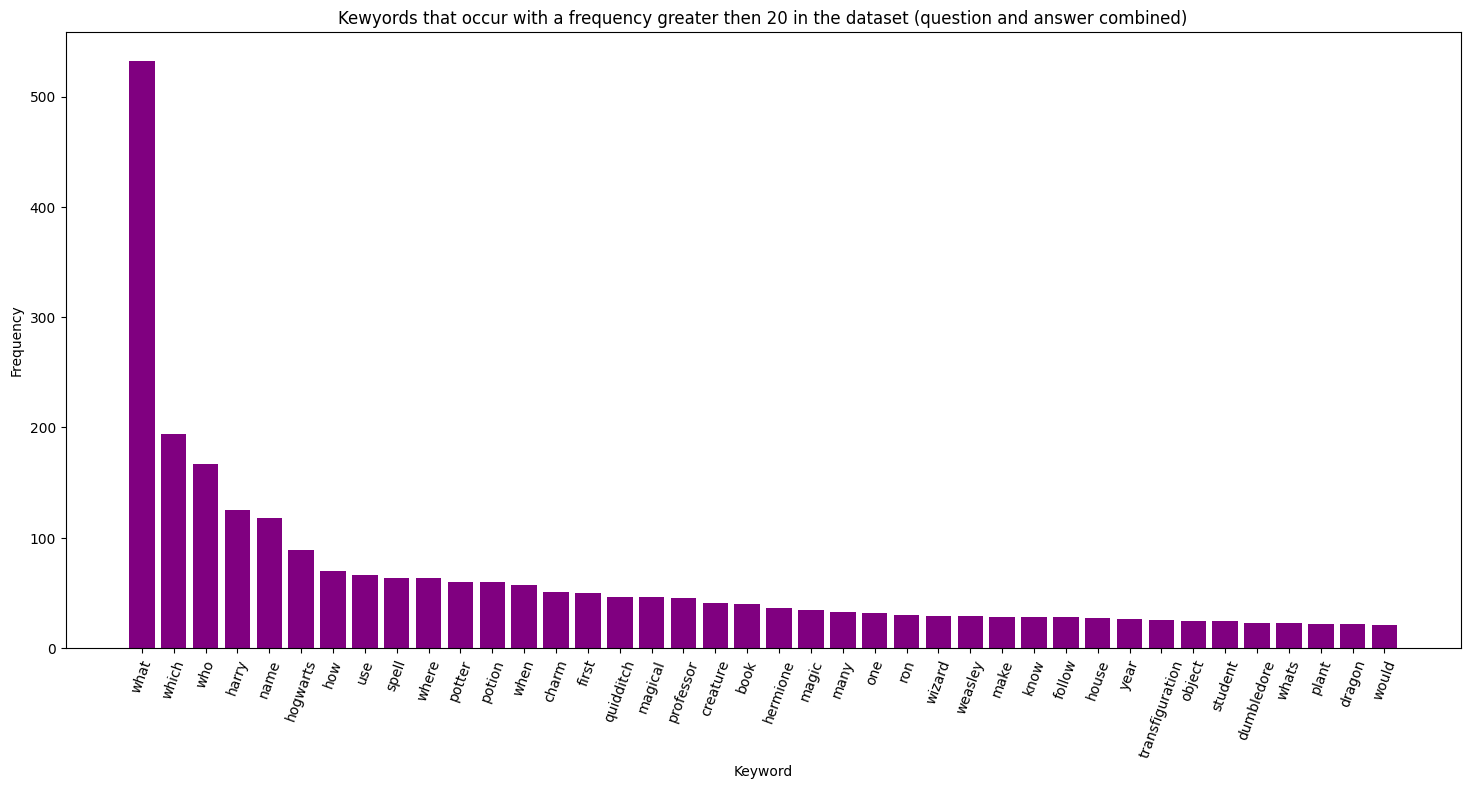

In [29]:
plt.figure(figsize=(18,8))

plt.bar(filtered_keyword_count_df['Keyword'], filtered_keyword_count_df['Frequency'], color="purple")

plt.xlabel('Keyword')
plt.ylabel('Frequency')
plt.title(f"Kewyords that occur with a frequency greater then {frequency_cutoff} in the dataset (question and answer combined)")
plt.xticks(rotation=70)
plt.show()

**Notes on keyword frequency**
1. The `what`, `which`, `who`, `name`, `how` and `where` are in top 10 of the frequency counts, so it looks like majority questions are likely to be factual types. These questions in all likelihood should have short answers. We can take a closer look at the dataset to confirm. `What` by far is the most common type of question keyword.
2. Its not a suprise that `harry` and `hogwarts` are also in the top - they would be the most common contextual keyword.
3. `spell` also might be a factual question? what kind of spell - may be check if all occurrence of spell are the factual question keywords? The same logic would be for `potion` and `charm`. 
4. There are some very wordy answers, it'll be interesting to look at their question format / type.
5. Note - `whats` and `would` also appear near the tail end of the graph although `would` questions could be quite open-ended?

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>

### 6.2. Factual recall questions

In trivia, some of the most common questions are usually concerned with recalling specific facts to test the player. These questions typically ask about names, places, events, or spells. 

From the figure above, we can see that the top interrogative keywords like 'what', 'which', 'who', along with frequent subject-related keywords like 'harry' and 'name', dominate. This strongly suggests that many questions could be *factual recall* types. So, we can expect these questions to have typical formats such 'What is Albus Dumbledore's full name?" or "Where did Harry live during the summer holidays?".  We can assess the occurence of such typical keywords in the `question keywords` along with their frequency. These keywords could be:

- "Who...?" -> related to a character name.
- "What...?" -> an object, fact, event
- "Where...?" -> a location
- "When...?" / "In what year...?" -> would relate a timing of an event (books timeline)
- "How many...?" -> Number (although 'how' on its own can be open-ended. so might have to check for presence of both)
- "Name the..." -> a list / name(s)
<br>

**Methodology for analysis**:

First frequency of occurence of the "factual recall keywords" was determined based on a predefined list that was iteratively updated based on the analysis ([section 6.2.1](#621-Distribution-of-factual-recall-type-questions)). Then a more granular analysis was done by filtering and analysing questions for each question keyword ([section 6.2.2](#622-what-do-the-what-questions-look-like) to [section 6.2.5](#625-what-do-when-questions-look-like)).

A set of custom functions were developed to assess these keyword questions in a systematic, efficient, and standardized way. These functions are located in the `eda_scripts.py` module and imported into the notebook. The main steps for analyzing questions by 'factual recall' keywords (e.g. "what", "where") is to use the:

1. `eda.get_question_type_info(df_for_analysis,q_keyword, n_samples)` method to obtain summary analysis. This method uses the occurence of the keyword in the `question keyword` column to filter the relevant record. This includes:
    - the number (and percentage) of questions in the dataset with the selected "keyword" in it, 
    - the maximum, minimum, and descriptive statistics for the answer lengths associated with the question,
    - a sample of the filtered dataframe used by the method.
2. `eda.create_ans_len_boxplot(df_for_analysis,q_keyword)` method to generate side-by-side box plots of the filtered "keyword" questions and associated answers.
3.  `eda.print_keyword_ngrams(df_for_analysis['question'],keyword,(min_ngram_size, max_ngram_size))` to find n-grams in the raw question string in the `question` column, a custom list of stop words (default is None), and a range of n-gram size that are of iterest. By default the method looks at the top 10 but this parameter can also be changed. N-grams allow contextual understanding of the question, e.g. confirm it is a factual recall type? with stop words filtering it gives more information on the harry potter context and shows how the keywords are frequently chained together.

#### Section 6.2 quick links

[6.2.1. Distribution of factual recall type questions](#621-Distribution-of-factual-recall-type-questions)<br>
[6.2.2. What do the "what" questions look like?](#622-What-do-the-what-questions-look-like)<br>
[6.2.3. What do the "who" questions look like? ](#623-What-do-the-who-questions-look-like)<br>
[6.2.4. What do the "where" questons look like?](#624-What-do-the-where-questions-look-like)<br>
[6.2.5. What do the "when" questions look like?](#625-what-do-when-questions-look-like)<br>

The main analysis parameters are defined upfront for ease of use and error management. This includes:
- `df_for_analysis`: The cleaned and processed dataset that is the same across the analysis but called multiple times in functions.
- `n_samples`: The number of random samples to display from the dataframe filtered by keyword (the methods have built-in corrections if the dataframe size is smaller then n_samples).

In [30]:
# Parameters for analysis:
df_for_analysis = trivia_keywords_df
n_samples = 20

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>

#### 6.2.1. Distribution of factual recall type questions 

Now let's take a wider look at the dataset and see how many answers we can consider to be *factual recall* . We can create a list of words to look for. The list might not be exhaustive but will gives us a good sense of the dataset.

In [31]:
# list of words to look for when identifying 'factual recall' questions 
factual_recall_list = ['what', 'name', 'who', 'where', 'when', 'whats']

# Initialize column:
trivia_keywords_df['factual_recall_keyword'] = None

# iterate through each row and notes how many keywords are present from the list and records them in the new `factual_recall_keyword` 
# column using list comprehension, else label as 'N/A'.
trivia_keywords_df['factual_recall_keyword'] = trivia_keywords_df['question keywords'].apply(
    lambda x: [word for word in factual_recall_list if word in x] or 'N/A'
)

In [32]:
trivia_keywords_df.head()

,question,answer,question keywords,answer keywords,combined_unique_keywords,factual_recall_keyword
0,What are the three European wizarding schools that participate in the Triwizard Tournament?,"Hogwarts, Beauxbatons, and Durmstrang.","[what, school, european, three, triwizard, participate, wizarding, tournament]","[beauxbatons, durmstrang, hogwarts]","[beauxbatons, what, durmstrang, school, european, three, triwizard, participate, hogwarts, wizarding, tournament]",[what]
1,When was Hogwarts founded?,10th century,"[found, hogwarts, when]","[th, century]","[found, th, century, hogwarts, when]",[when]
2,What is a Wronski Feint?,Pretending to dive for the Snitch,"[what, wronski, feint]","[dive, pretend, snitch]","[what, snitch, dive, pretend, feint, wronski]",[what]
3,You wouldn't know anything about this. Name a method to make your broom go faster.,Using polish,"[faster, make, method, know, broom, name, go, wouldnt, anything]","[polish, use]","[faster, make, method, anything, know, polish, name, use, go, broom, wouldnt]",[name]
4,Harry first took the Knight Bus in The Prisoner of Azkaban. How much does a ticket cost if it includes hot chocolate?,14 sickles.,"[hot, bus, knight, prisoner, much, first, take, cost, include, harry, azkaban, how, ticket, chocolate]",[sickle],"[hot, bus, knight, prisoner, much, first, take, cost, include, harry, azkaban, how, ticket, chocolate, sickle]",N/A


In [33]:
## How many of the records have vs. don't have a 'N/A' tag for the 'factual_recall_keyword'?

# where 'factual_recall_keyword' is N/A
not_factual_q_count = trivia_keywords_df[trivia_keywords_df['factual_recall_keyword']=='N/A']['question'].count()
not_factual_q_percentage = (not_factual_q_count / trivia_keywords_df.shape[0]) * 100
# where 'factual_recall_keyword' is not N/A
factual_q_count = trivia_keywords_df.shape[0] - not_factual_q_count
factual_q_percentage = 100 - not_factual_q_percentage

# display results
print("Factual recall questions:\n",
      f"- There are at least {factual_q_count} questions ({factual_q_percentage: .0f}% of total count) that can be considered factual recall types.\n",
      f"- There are {not_factual_q_count} questions ({not_factual_q_percentage: .0f}% of total count) that can be considered as not being factual recall types."
)

Factual recall questions:
 - There are at least 802 questions ( 74% of total count) that can be considered factual recall types.
 - There are 283 questions ( 26% of total count) that can be considered as not being factual recall types.


In [34]:
## How are the factual questions distributed?

# 1. Create a dictionary to store values for easy plotting
factq_dict = {}
total = trivia_keywords_df.shape[0]

for keyword in factual_recall_list:
    # check if keyword contains a list and then if keyword is in the list:
    filter_condition = lambda x: keyword in x if isinstance(x, list) else False
    count = trivia_keywords_df[trivia_keywords_df['factual_recall_keyword'].apply(filter_condition)].shape[0]
    factq_dict[keyword] = {
        'count': count,
        'percentage of total': (count / total) * 100
    }


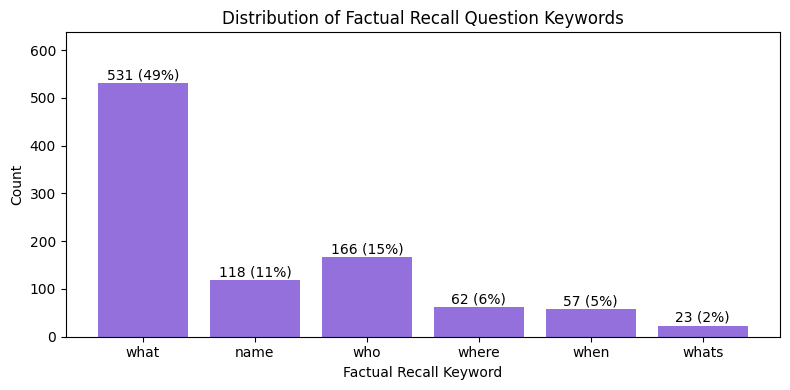

In [35]:
# 2. Visualize as a barchart 

# Gather data from dict
keywords = list(factq_dict.keys())
counts = [factq_dict[k]['count'] for k in keywords]
percentages = [factq_dict[k]['percentage of total'] for k in keywords]

# Plot
plt.figure(figsize=(8, 4))
bars = plt.bar(keywords, counts, color='mediumpurple' )

# Add "count (n%)"" labels above bars
for bar, count, pct in zip(bars, counts, percentages):
    label = f"{count} ({pct:.0f}%)"
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
             label, ha='center', va='bottom', fontsize=10)

# Axis labels and title
plt.ylabel("Count")
plt.xlabel("Factual Recall Keyword")
plt.title(f"Distribution of Factual Recall Question Keywords")
plt.ylim(0, max(counts) * 1.2)  # Add some space above bars

plt.tight_layout()
plt.show()

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#section-62-quick-links" style="display:inline-block; padding:8px 16px; background-color:#a390d4; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to Section 6.2 Quick Links</a>

#### 6.2.2 What do the `"what"` questions look like?

Let's start by looking at "What" type questions as they are the most common (as per figure 3).

In [36]:
q_keyword = "what"
eda.get_question_type_info(df_for_analysis,q_keyword, n_samples)

There are 531 'what'-type questions in the data set ( 49% of total).
These questions have answers that range in lengths between 1 and 22.

Basic descriptive statistics of the answers with 'what' type questions: 
 count    531.000000
mean       2.548023
std        2.370226
min        1.000000
25%        1.000000
50%        2.000000
75%        3.000000
max       22.000000
Name: answer, dtype: float64

A random sample of the `what`- type questions: 


,question,answer,question keywords,answer keywords,combined_unique_keywords,factual_recall_keyword
1251,What color is the potion for dreamless sleep?,Purple,"[what, sleep, potion, dreamless, color]",[purple],"[what, sleep, potion, dreamless, color, purple]",[what]
96,What type of magical creature is Dobby?,House-elf,"[what, type, creature, dobby, magical]",[houseelf],"[houseelf, what, type, creature, dobby, magical]",[what]
241,What is the name of the three-headed dog that guards the Sorcerer's Stone?,Fluffy,"[guard, what, dog, threeheaded, stone, name, sorcerer]",[fluffy],"[guard, what, dog, fluffy, threeheaded, stone, name, sorcerer]","[what, name]"
281,Ginny Weasley bought a pet Pygmy Puff from her older brothers' joke shop. What did she name it?,Arnold.,"[what, brother, pet, buy, puff, weasley, pygmy, old, name, joke, ginny, shop]",[arnold],"[what, arnold, brother, pet, puff, buy, weasley, pygmy, old, name, joke, ginny, shop]","[what, name]"
258,What is Professor McGonagall’s animagus?,Silver tabby cat,"[what, animagus, professor, mcgonagalls]","[tabby, cat, silver]","[tabby, what, cat, animagus, mcgonagalls, professor, silver]",[what]
451,What magical artefact creates the Elixir of Life?,Philosopher's Stone,"[elixir, what, life, artefact, magical, create]","[philosopher, stone]","[elixir, what, life, philosopher, stone, artefact, magical, create]",[what]
953,"When Harry was learning the Patronus Charm, what happy memory did he initially use?",The first time he rode a broom,"[what, patronus, harry, memory, initially, charm, use, happy, when, learn]","[time, rode, broom, first]","[what, patronus, first, time, rode, harry, memory, initially, charm, use, happy, broom, when, learn]","[what, when]"
1209,What did Sirius Black’s mother do to his name on the Black family tapestry?,Burned it away,"[black, what, mother, tapestry, family, name, sirius]","[burn, away]","[black, what, mother, tapestry, family, burn, name, away, sirius]","[what, name]"
917,What makes a transformation easier?,Similarity in appearance,"[transformation, what, make, easy]","[similarity, appearance]","[what, make, similarity, appearance, easy, transformation]",[what]
803,In what potion is the Sneezewort featured?,Befuddlement Draught.,"[what, sneezewort, feature, potion]","[befuddlement, draught]","[what, potion, draught, sneezewort, befuddlement, feature]",[what]


As we know a significant portion of the dataset are "what" questions. 
For these questions, 

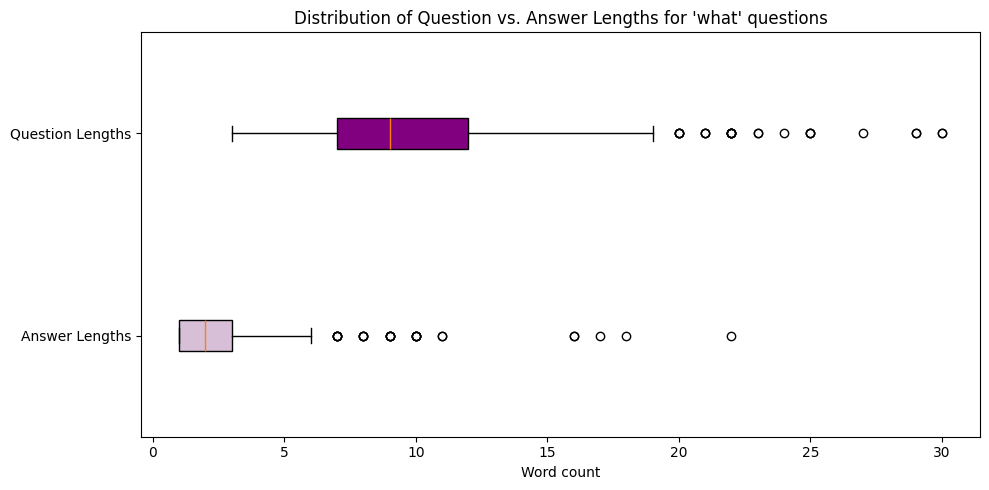

In [37]:
eda.create_ans_len_boxplot(df_for_analysis,q_keyword)

Ok, there is quite a range in answer length and we can't make any generalization about them. 

In [38]:
eda.print_keyword_ngrams(df_for_analysis['question'],'what',(2,5))


Analyzing common phrases (n-grams) starting with 'what' in this set of questions:
Using stop_words: None
Top 10 common n-grams starting with 'what':
- 'what is': 174
- 'what is the': 111
- 'what does': 50
- 'what is the name': 46
- 'what is the name of': 46
- 'what was': 27
- 'what did': 24
- 'what does the': 21
- 'what was the': 18
- 'what are': 17


In [39]:
# let's remove 'is', 'the', 'are', 'was' as our custom stop word list:
stop_words = ['is', 'the', 'are', 'was', 'does', 'did', 'do', 'kind', 'of', 'for','type'] 
eda.print_keyword_ngrams(df_for_analysis['question'],'what',(2,5), 10, stop_words)


Analyzing common phrases (n-grams) starting with 'what' in this set of questions:
Using stop_words: ['is', 'the', 'are', 'was', 'does', 'did', 'do', 'kind', 'of', 'for', 'type']
Top 10 common n-grams starting with 'what':
- 'what name': 63
- 'what spell': 17
- 'what magical': 16
- 'what creature': 15
- 'what incantation': 13
- 'what harry': 10
- 'what potion': 9
- 'what magical creature': 8
- 'what animal': 6
- 'what charm': 6


These N-grams also indicate that the "what" questions are asking for factual details.

Now let's also look at `name` keyword, it is the second-most frequent keyword but there might be an overlap with the `what` questions.

In [40]:
## What do questions with the 'name' keyword look like?

# Filter question that the word 'name' in them
name_questions = df_for_analysis.loc[df_for_analysis['question keywords'].apply(lambda x: keyword in x)]

# Now filter that subset of question to find the occurence of "name" without "what" / "what's" present.
name_nowhat_questions = name_questions[
    ~name_questions['question keywords'].apply(lambda x: 'what' in x or 'whats' in x)
]
# display results
print("Occurence of 'name' without 'what' in the trivia questions: ",name_nowhat_questions.shape[0])

Occurence of 'name' without 'what' in the trivia questions:  0


It look like that in this dataset "name" always appears with "what". So we don't have to consider them separately for now. However, it is entirely possible to phrase the question with just "name", e.g. "Name the characters from ....." and can be possible when the dataset is expanded.

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#section-62-quick-links" style="display:inline-block; padding:8px 16px; background-color:#a390d4; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to Section 6.2 Quick Links</a>

#### 6.2.3. What do the `"who"` questions look like?

Let's start by looking at "What" type questions as they are the most common (as per figure 3).

In [41]:
# What do "who" questions look like? 
eda.get_question_type_info(df_for_analysis,"who", n_samples)

There are 166 'who'-type questions in the data set ( 15% of total).
These questions have answers that range in lengths between 1 and 11.

Basic descriptive statistics of the answers with 'who' type questions: 
 count    166.000000
mean       2.524096
std        1.857668
min        1.000000
25%        2.000000
50%        2.000000
75%        2.000000
max       11.000000
Name: answer, dtype: float64

A random sample of the `who`- type questions: 


,question,answer,question keywords,answer keywords,combined_unique_keywords,factual_recall_keyword
82,"In the Order of Phoenix, who gives the flying lessons to Harry's group?",Rolanda Hooch,"[lesson, give, who, fly, group, order, harrys, phoenix]","[rolanda, hooch]","[rolanda, lesson, hooch, who, give, fly, group, order, harrys, phoenix]",[who]
694,Who killed Emeric the Evil in a duel?,Egbert the Egregious,"[evil, emeric, who, kill, duel]","[egbert, egregious]","[evil, emeric, who, kill, duel, egbert, egregious]",[who]
219,Who does Hermione impersonate using the Polyjuice Potion in the second book of the Harry Potter series?,Millicent Bulstrode,"[book, polyjuice, impersonate, potion, hermione, second, who, harry, series, use, potter]","[bulstrode, millicent]","[book, polyjuice, impersonate, potion, hermione, second, bulstrode, who, harry, series, use, potter, millicent]",[who]
1093,Who is the Transfiguration Professor?,Minerva McGonagall,"[transfiguration, who, professor]","[mcgonagall, minerva]","[transfiguration, who, professor, mcgonagall, minerva]",[who]
569,"In the movie, Professor McGonagall explains the origins of the Chamber of Secrets. Who does it in the book?","Professor Binns, the history teacher (who is also a ghost)","[book, origins, who, chamber, professor, mcgonagall, movie, secret, explain]","[ghost, who, teacher, professor, also, history, binns]","[book, also, ghost, history, origins, who, binns, chamber, professor, mcgonagall, teacher, movie, secret, explain]",[who]
439,Who is Stan Shunpike?,The conductor of the Knight Bus,"[shunpike, who, stan]","[bus, knight, conductor]","[bus, knight, conductor, who, stan, shunpike]",[who]
1138,Who makes laws for the magical world?,The Ministry of Magic.,"[make, world, who, law, magical]","[magic, ministry]","[magic, make, world, who, ministry, law, magical]",[who]
81,Who does Harry live with before going to Hogwarts?,"His aunt and uncle, Petunia and Vernon Dursley, and cousin Dudley.","[live, harry, who, go, hogwarts]","[cousin, dudley, vernon, aunt, petunia, uncle, dursley]","[cousin, live, dudley, vernon, aunt, petunia, uncle, harry, who, dursley, go, hogwarts]",[who]
517,Who lied to Voldemort during the final battle by proclaiming that Harry Potter was dead?,Narcissa Malfoy,"[dead, voldemort, battle, who, harry, lie, final, potter, proclaim]","[malfoy, narcissa]","[malfoy, dead, voldemort, battle, harry, who, lie, final, potter, proclaim, narcissa]",[who]
622,Who is the giant three-headed dog that guards the trapdoor leading to the Philosopher's Stone in the first book?,Fluffy,"[guard, dog, book, giant, lead, threeheaded, first, who, philosopher, stone, trapdoor]",[fluffy],"[guard, fluffy, dog, book, giant, lead, threeheaded, first, who, philosopher, stone, trapdoor]",[who]


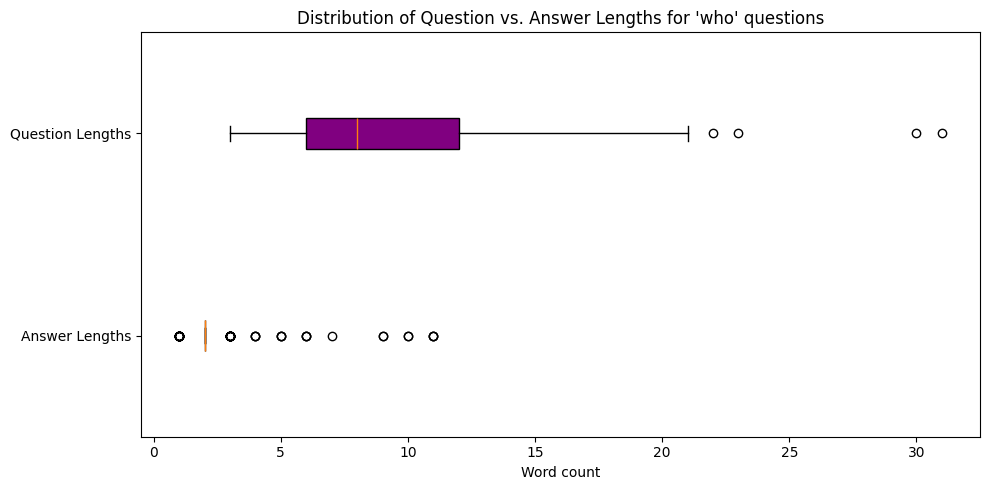

In [42]:
eda.create_ans_len_boxplot(df_for_analysis,"who")

**Note**: Although we know there is considerable overlap between 'what' and 'name' - 'name' remains in assessment for completeness.

In [43]:
# With no stop_words considered:
eda.print_keyword_ngrams(df_for_analysis['question'],"who", (2,5))


Analyzing common phrases (n-grams) starting with 'who' in this set of questions:
Using stop_words: None
Top 10 common n-grams starting with 'who':
- 'who is': 56
- 'who is the': 38
- 'who was': 20
- 'who was the': 12
- 'who wrote': 8
- 'who does': 7
- 'who invented': 5
- 'who is harry': 4
- 'who teaches': 4
- 'who created': 3


In [44]:
# Using a custom list of stop words.
stop_words = ['is', 'was', 'does', 'the', 'of', 'in']
eda.print_keyword_ngrams(df_for_analysis['question'],"who", (3,7), stop_words=stop_words)


Analyzing common phrases (n-grams) starting with 'who' in this set of questions:
Using stop_words: ['is', 'was', 'does', 'the', 'of', 'in']
Top 10 common n-grams starting with 'who':
- 'who headmaster hogwarts': 6
- 'who harry potter': 3
- 'who harry potter godfather': 3
- 'who original owner': 3
- 'who created sorcerer': 2
- 'who created sorcerer stone': 2
- 'who destroyed horcrux': 2
- 'who destroyed horcrux helga': 2
- 'who divination professor': 2
- 'who flying instructor': 2


<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#section-62-quick-links" style="display:inline-block; padding:8px 16px; background-color:#a390d4; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to Section 6.2 Quick Links</a>

#### 6.2.4. What do the "where" questions look like? 

In [45]:
eda.get_question_type_info(df_for_analysis, "where", n_samples)

There are 62 'where'-type questions in the data set ( 6% of total).
These questions have answers that range in lengths between 1 and 14.

Basic descriptive statistics of the answers with 'where' type questions: 
 count    62.000000
mean      3.177419
std       2.398936
min       1.000000
25%       2.000000
50%       3.000000
75%       3.750000
max      14.000000
Name: answer, dtype: float64

A random sample of the `where`- type questions: 


,question,answer,question keywords,answer keywords,combined_unique_keywords,factual_recall_keyword
479,Where was Harry Potter born?,Godric's Hollow.,"[where, harry, bear, potter]","[hollow, godrics]","[where, harry, bear, hollow, godrics, potter]",[where]
128,Where does Valerian grow best?,In the sun,"[where, grow, best, valerian]",[sun],"[where, sun, grow, valerian, best]",[where]
759,Where is the entrance to the Chamber of Secrets?,"In the second-floor girl's bathroom, also known as Moaning Myrtle's bathroom.","[where, secret, entrance, chamber]","[myrtle, know, moan, also, girl, secondfloor, bathroom]","[where, myrtle, chamber, know, moan, also, secret, entrance, girl, secondfloor, bathroom]",[where]
284,Where can Shrivelfigs be found?,Abyssinia,"[where, shrivelfigs, find]",[abyssinia],"[where, abyssinia, shrivelfigs, find]",[where]
396,Where was Harry born?,Godric's Hollow,"[where, harry, bear]","[hollow, godrics]","[where, harry, bear, hollow, godrics]",[where]
500,"In Harry Potter and the Chamber of Secrets, where were Harry, Hermione, and Ron coming from when they found Mrs. Norris petrified?",Nearly Headless Nick's Deathday Party,"[where, mrs, ron, find, hermione, petrify, harry, chamber, potter, secret, norris, when, come]","[headless, nick, party, nearly, deathday]","[where, mrs, ron, find, hermione, petrify, headless, harry, nick, chamber, party, nearly, deathday, potter, secret, norris, when, come]","[where, when]"
1013,"In the book, where do Hermione Granger’s parents move to?",Australia,"[where, book, grangers, hermione, move, parent]",[australia],"[where, book, grangers, hermione, move, parent, australia]",[where]
328,Where are the highest quality Shrivelfigs grown?,Abyssinia,"[where, shrivelfigs, grow, quality, high]",[abyssinia],"[where, shrivelfigs, abyssinia, grow, quality, high]",[where]
111,Where are Kappas most commonly found?,Japan,"[where, kappa, commonly, find]",[japan],"[where, kappa, find, commonly, japan]",[where]
232,Where was Beedle the Bard born?,"Yorkshire, England.","[where, born, beedle, bard]","[yorkshire, england]","[where, england, yorkshire, beedle, born, bard]",[where]


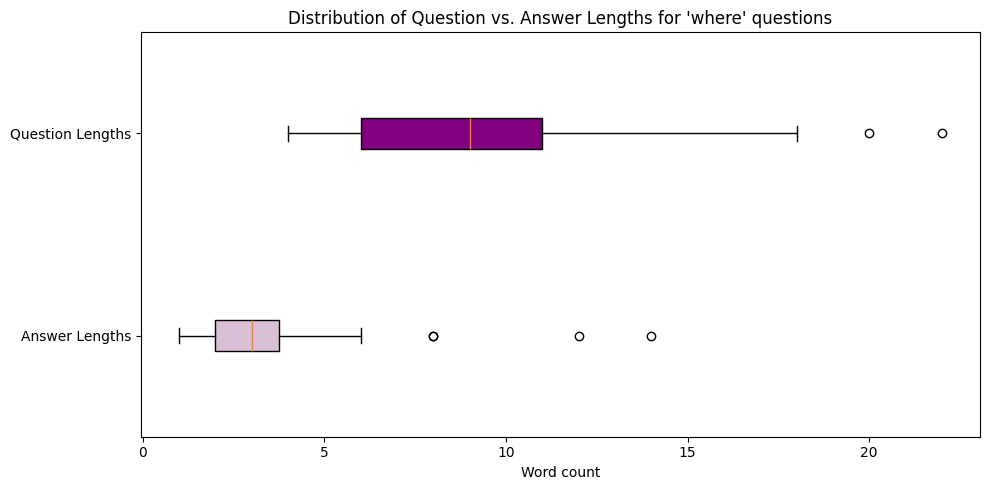

In [46]:
eda.create_ans_len_boxplot(df_for_analysis,"where")

In [47]:
eda.print_keyword_ngrams(df_for_analysis['question'], "where")


Analyzing common phrases (n-grams) starting with 'where' in this set of questions:
Using stop_words: None
Top 10 common n-grams starting with 'where':
- 'where is': 14
- 'where is the': 12
- 'where did': 9
- 'where do': 8
- 'where does': 8
- 'where was': 5
- 'where are': 4
- 'where can': 3
- 'where was harry': 3
- 'where are the': 2


<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#section-62-quick-links" style="display:inline-block; padding:8px 16px; background-color:#a390d4; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to Section 6.2 Quick Links</a>

#### 6.2.5. What do "when" questions look like?

In [48]:
eda.get_question_type_info(df_for_analysis,"when",n_samples)

There are 57 'when'-type questions in the data set ( 5% of total).
These questions have answers that range in lengths between 1 and 13.

Basic descriptive statistics of the answers with 'when' type questions: 
 count    57.000000
mean      2.824561
std       2.522207
min       1.000000
25%       1.000000
50%       2.000000
75%       3.000000
max      13.000000
Name: answer, dtype: float64

A random sample of the `when`- type questions: 


,question,answer,question keywords,answer keywords,combined_unique_keywords,factual_recall_keyword
463,What does the boggart turn into when Mrs. Weasley sees it?,Her entire family and Harry lying dead on the floor,"[what, turn, mr, boggart, weasley, see, when]","[dead, family, harry, lie, floor, entire]","[what, turn, entire, dead, family, mr, harry, lie, boggart, floor, weasley, see, when]","[what, when]"
153,What was the Hippogriff Buckbeak called when he returned to Hogwarts?,Witherwing,"[what, buckbeak, hippogriff, call, return, hogwarts, when]",[witherwing],"[what, buckbeak, hippogriff, call, return, witherwing, hogwarts, when]","[what, when]"
11,"When Riding Facing Backwards, how does steering work?",Turn to the opposite direction.,"[rid, how, work, when, steering, backwards, face]","[direction, turn, opposite]","[turn, rid, opposite, backwards, how, work, direction, steering, when, face]",[when]
1014,Who is the Headmaster of Hogwarts when Harry arrives?,Albus Dumbledore.,"[arrive, harry, who, headmaster, hogwarts, when]","[albus, dumbledore]","[arrive, harry, who, dumbledore, albus, headmaster, hogwarts, when]","[who, when]"
214,Who was headmaster or headmistress at Hogwarts when Tom Riddle was a student?,Armando Dippet,"[who, riddle, student, headmaster, headmistress, tom, hogwarts, when]","[armando, dippet]","[armando, who, riddle, student, headmaster, headmistress, dippet, tom, hogwarts, when]","[who, when]"
265,"When practising Bibliomancy, what passage should one select?",A random passage,"[what, one, passage, select, practise, bibliomancy, when]","[passage, random]","[what, one, passage, select, random, practise, bibliomancy, when]","[what, when]"
953,"When Harry was learning the Patronus Charm, what happy memory did he initially use?",The first time he rode a broom,"[what, patronus, harry, memory, initially, charm, use, happy, when, learn]","[time, rode, broom, first]","[what, patronus, first, time, rode, harry, memory, initially, charm, use, happy, broom, when, learn]","[what, when]"
666,What color is Teddy Lupin's hair when he is born?,Black,"[what, lupins, color, born, teddy, hair, when]",[black],"[black, what, lupins, color, born, teddy, hair, when]","[what, when]"
89,What does it mean when a magical creature is classified as XXX by the Ministry of Magic?,Competent Wizards Should Cope,"[mean, what, magic, creature, classify, xxx, ministry, magical, when]","[cope, competent, wizard]","[mean, what, magic, creature, wizard, cope, classify, xxx, ministry, magical, competent, when]","[what, when]"
500,"In Harry Potter and the Chamber of Secrets, where were Harry, Hermione, and Ron coming from when they found Mrs. Norris petrified?",Nearly Headless Nick's Deathday Party,"[where, mrs, ron, find, hermione, petrify, harry, chamber, potter, secret, norris, when, come]","[headless, nick, party, nearly, deathday]","[where, mrs, ron, find, hermione, petrify, headless, harry, nick, chamber, party, nearly, deathday, potter, secret, norris, when, come]","[where, when]"


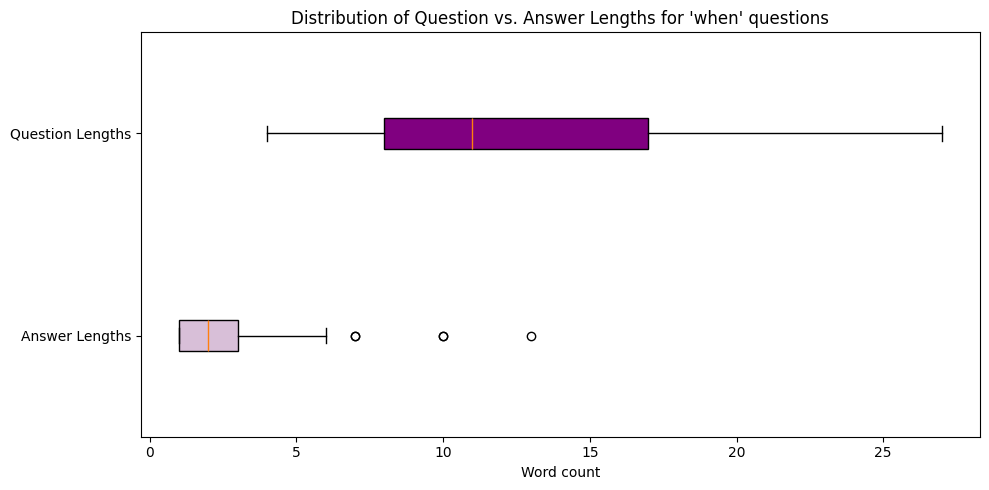

In [49]:
eda.create_ans_len_boxplot(df_for_analysis,"when")

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#section-62-quick-links" style="display:inline-block; padding:8px 16px; background-color:#a390d4; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to Section 6.2 Quick Links</a>

### 6.3 Questions that do not have factual recall keywords

The 'factual recall keywords' is not exhaustive. So looking at the questions with an 'N/A' tag can help us:
1. Determine if any other keywords should be added to the list added to the list that we might not have caught this time.
2. Is there a pattern in the remaining questions? what kind of questions are they? 
3. Are these open-ended type questions? e.g."Why....?" or "Would...?"

We can start looking at the tokens specific to this subset of the data frame and how frequently they occur.

#### Section 6.3 quick links

[6.3.1. What do the "which" questions look like?](#631-what-do-the-which-questions-look-like)<br>
[6.3.2. What do the "who" questions look like?](#632-what-do-the-why-questions-look-like)<br>
[6.3.3. What do the "how" questions look like?](#633-what-do-the-how-type-questions-look-like)<br>
[6.3.4. How many questions contain multiple keywords? ](#634-how-many-questions-contain-multiple-keywords)<br>
[6.3.5. What do the remaining "N/A" questions look like? ](#635-what-do-the-remaining-na-questions-look-like)<br>
[6.3.6. Plan of action ](#636-plan-of-action)

In [50]:
# What are the common tokens in the N/A tagged questions?

# A. Filter the relevant questions where the 'factual_recall_keyword' is 'N/A'
q_filtered_df = trivia_keywords_df[trivia_keywords_df['factual_recall_keyword']=='N/A']
q_filtered_df.sample(10)

,question,answer,question keywords,answer keywords,combined_unique_keywords,factual_recall_keyword
938,This real-life library served as the restricted section of the Hogwarts library in the film version. Which is it?,The Bodleian Library at Oxford University,"[reallife, version, library, serve, restricted, film, which, hogwarts, section]","[university, bodleian, library, oxford]","[reallife, bodleian, version, library, serve, restricted, university, film, which, hogwarts, oxford, section]",N/A
480,How can you tell if a door is Imperturbable?,Chuck stuff at it.,"[door, how, imperturbable, tell]","[chuck, stuff]","[imperturbable, tell, stuff, door, chuck, how]",N/A
991,Which insect is Ron afraid of?,Spiders,"[afraid, insect, which, ron]",[spider],"[ron, insect, afraid, which, spider]",N/A
267,Which Weasley dies during the final battle of Hogwarts?,Fred Weasley,"[battle, final, weasley, which, die, hogwarts]","[weasley, fred]","[battle, final, which, weasley, die, hogwarts, fred]",N/A
54,Which creature's hair is often woven into Invisibility Cloaks?,Demiguise,"[woven, often, cloak, which, invisibility, creatures, hair]",[demiguise],"[woven, demiguise, often, cloak, invisibility, which, creatures, hair]",N/A
784,How many players are on a Quidditch team?,Seven,"[many, player, how, quidditch, team]",[seven],"[many, player, how, quidditch, team, seven]",N/A
573,"In 1876, which caretaker tried to make Peeves leave Hogwarts?",Rancorous Carpe,"[make, try, peeve, which, leave, caretaker, hogwarts]","[carpe, rancorous]","[make, try, peeve, carpe, which, leave, rancorous, caretaker, hogwarts]",N/A
794,Which sweet-smelling plant changes its scent?,Flutterby Bush,"[sweetsmelling, change, plant, which, scent]","[bush, flutterby]","[sweetsmelling, flutterby, change, plant, bush, which, scent]",N/A
6,Which of these is an ingredient in Befuddlement Draughts?,Sneezewort,"[befuddlement, draught, which, ingredient]",[sneezewort],"[draught, sneezewort, ingredient, befuddlement, which]",N/A
700,Which potion causes the drinker to speak nonsense?,Babbling Beverage,"[nonsense, speak, potion, cause, which, drinker]","[babbling, beverage]","[nonsense, potion, speak, babbling, beverage, cause, which, drinker]",N/A


In [51]:
# B. Count the occurence of each question token

# 1. create a copy so original df is not modified.
na_frq_df = q_filtered_df[['question', 'question keywords']].copy()

# 2. Use  the explode method to expand the list into individual column entries:
na_q_df = na_frq_df.explode('question keywords')

# 3. Now we can count values of the each token occurence in the `question keywords` column:
na_q_counts = na_q_df['question keywords'].value_counts()

# 3. print results
# Rename the index and values columns for clarity:
na_q_counts.index.name = "keyword"
na_q_counts.name = "Frequency"
total_na_q = q_filtered_df.shape[0]

print(f'* There are a total of {total_na_q} questions that are tagged as "N/A" in the "factual_recall_keywords" column.\n')
print("* Summary of the 'N/A' question keyword tokens (cutoff to display only with counts > 10): \n")
print(na_q_counts[na_q_counts>10])

# print percentage of 'which' and 'why' keywords:
which_q_percent_of_na = (na_q_counts['which'] / total_na_q) * 100
why_q_percent_of_na =  (na_q_counts['why'] / total_na_q) * 100

print(f"\n* Percentage of 'which' questions in the 'N/A' filtered dataset: {which_q_percent_of_na: .1f}%")
print(f"* Percentage of 'why' questions in the 'N/A' filtered dataset: {why_q_percent_of_na: .1f}%")

* There are a total of 283 questions that are tagged as "N/A" in the "factual_recall_keywords" column.

* Summary of the 'N/A' question keyword tokens (cutoff to display only with counts > 10): 

keyword
which        188
how           61
many          30
use           25
spell         25
follow        23
hogwarts      22
harry         22
potion        21
quidditch     21
charm         15
would         14
why           12
one           12
plant         11
first         11
Name: Frequency, dtype: int64

* Percentage of 'which' questions in the 'N/A' filtered dataset:  66.4%
* Percentage of 'why' questions in the 'N/A' filtered dataset:  4.2%


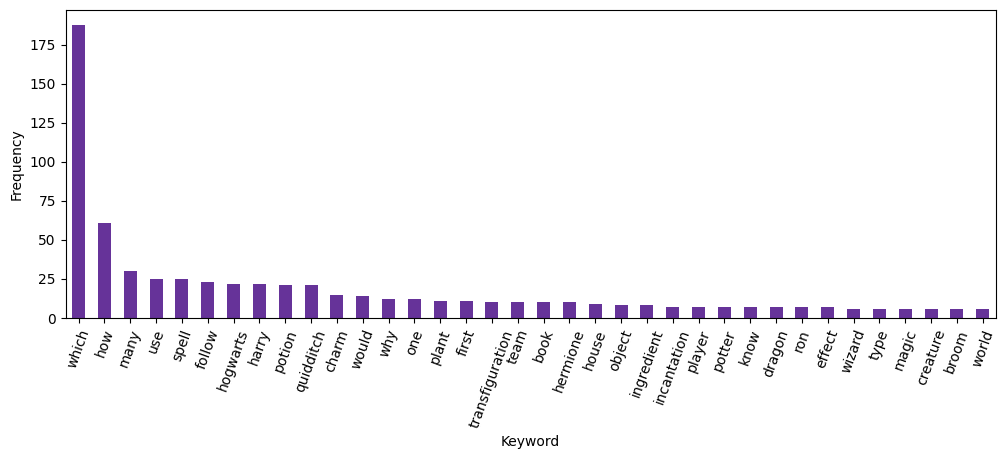

In [52]:
## We can plot it to get a better idea visually

# update figure_count for visual:
# figure_count += 1

# Lets filter for values greater than a threshold so the chart isn't cluttered by the tail
threshold = 5
high_frequency_tokens = na_q_counts[na_q_counts > threshold]

high_frequency_tokens.plot(kind='bar', figsize=(12,4), color='rebeccapurple')

plt.xlabel('Keyword')
plt.ylabel('Frequency')
# plt.title(f"Figure {figure_count}. Kewyords that occur with a frequency greater then {frequency_cutoff} in the dataset (question and answer combined)")
plt.xticks(rotation=70)
plt.show()

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#section-63-quick-links" style="display:inline-block; padding:8px 16px; background-color:#a390d4; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to Section 6.3 Quick Links</a>

#### 6.3.1. What do the "which" questions look like?

In [53]:
eda.get_question_type_info(df_for_analysis,"which",n_samples)

There are 194 'which'-type questions in the data set ( 18% of total).
These questions have answers that range in lengths between 1 and 9.

Basic descriptive statistics of the answers with 'which' type questions: 
 count    194.000000
mean       2.144330
std        1.502948
min        1.000000
25%        1.000000
50%        2.000000
75%        2.000000
max        9.000000
Name: answer, dtype: float64

A random sample of the `which`- type questions: 


,question,answer,question keywords,answer keywords,combined_unique_keywords,factual_recall_keyword
673,Which of the following is a side effect of Wiggenweld Potion?,Healing injuries,"[potion, follow, which, wiggenweld, side, effect]","[heal, injury]","[injury, potion, follow, which, wiggenweld, heal, side, effect]",N/A
713,Which of the plants is prone to slapping people in the face?,Bouncing Bulbs,"[prone, plant, slap, which, people, face]","[bulb, bounce]","[bulb, prone, plant, slap, which, people, bounce, face]",N/A
292,Which Quidditch players score goals?,The Chasers,"[player, goal, which, score, quidditch]",[chaser],"[player, goal, chaser, which, score, quidditch]",N/A
464,"When Professor Snape takes over Professor Lupin’s Defense Against the Dark Arts class, which page does he ask the students to turn to?",Page 394 (the page on werewolves),"[turn, lupin, take, dark, class, ask, defense, art, which, snape, professor, page, student, when]","[page, werewolf]","[werewolf, turn, lupin, take, dark, class, defense, art, which, snape, professor, when, page, student, ask]",[when]
398,The Medieval Assembly of European Wizards is related to which convention?,International Warlock Convention,"[assembly, relate, medieval, european, wizard, convention, which]","[international, convention, warlock]","[assembly, relate, medieval, european, warlock, wizard, convention, which, international]",N/A
132,Which house does Harry Potter belong to?,Gryffindor,"[house, harry, belong, which, potter]",[gryffindor],"[gryffindor, house, harry, belong, which, potter]",N/A
1086,Which of these plants has healing properties?,Dittany,"[heal, property, which, plant]",[dittany],"[property, plant, which, heal, dittany]",N/A
916,Which of these is not a species of dragon?,Finnish Flamethrower,"[dragon, which, species]","[flamethrower, finnish]","[flamethrower, species, which, dragon, finnish]",N/A
896,Which Quidditch team only has female players?,Holyhead Harpies,"[female, player, which, quidditch, team]","[harpy, holyhead]","[female, harpy, player, which, holyhead, quidditch, team]",N/A
1016,Harry uses Parseltongue to speak to which creatures?,Snake,"[speak, creature, parseltongue, harry, which, use]",[snake],"[speak, creature, parseltongue, harry, which, use, snake]",N/A


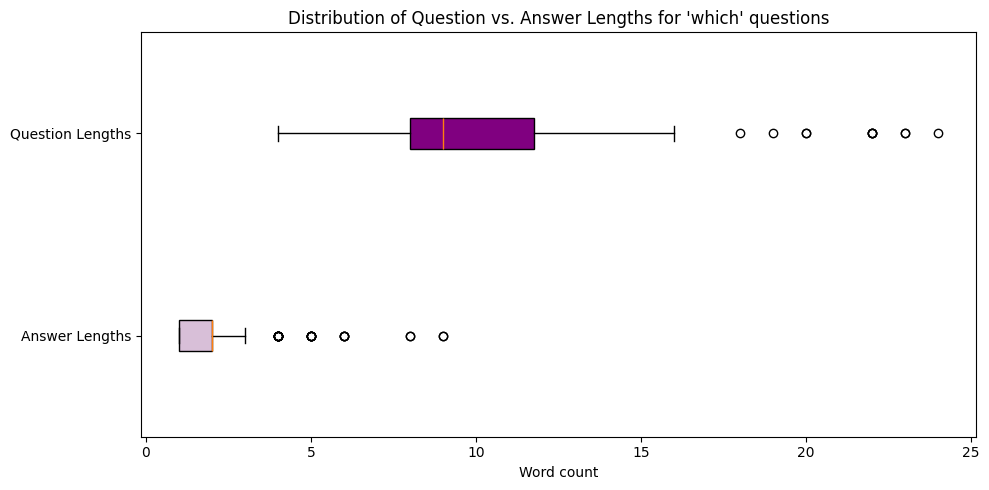

In [54]:
eda.create_ans_len_boxplot(df_for_analysis,"which")

In [55]:
eda.print_keyword_ngrams(df_for_analysis['question'],'which',(2,4))


Analyzing common phrases (n-grams) starting with 'which' in this set of questions:
Using stop_words: None
Top 10 common n-grams starting with 'which':
- 'which of': 65
- 'which of these': 38
- 'which of the': 25
- 'which of the following': 22
- 'which of these is': 11
- 'which is': 10
- 'which of these spells': 8
- 'which potion': 7
- 'which spell': 7
- 'which incantation': 6


In [56]:
eda.print_keyword_ngrams(df_for_analysis['question'],"which",(5,10))


Analyzing common phrases (n-grams) starting with 'which' in this set of questions:
Using stop_words: None
Top 10 common n-grams starting with 'which':
- 'which of the following is': 8
- 'which of these is not': 6
- 'which of the following is not': 5
- 'which of these spells is': 4
- 'which of these is an': 3
- 'which of these is not type': 3
- 'which of these is not type of': 3
- 'which of these scenarios would': 3
- 'which of these scenarios would you': 3
- 'which of these scenarios would you use': 3


**Observations: "Which" type questions**

- Marjority of the 'N/A' tagged questions are `which` type questions (194 questions). 
- In general we can expect `which` questions to be open-ended questions, but a closer look at these questions in the dataset confirms that they are also another form of a `factual recall question`.
- This in turn means that, with the inclusion of `which` into the keyword list, the vast majority of the questions (97%) can be considered as 'factual recall type questions' within this dataset.
- The longest answer is a list of characters full names.
- The sampled question generally seem to be difficult.

>NOTE: Can convert 👇🏼 code into a custom function later.

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#section-63-quick-links" style="display:inline-block; padding:8px 16px; background-color:#a390d4; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to Section 6.3 Quick Links</a>

#### 6.3.2. What do the "why" questions look like?

In [57]:
eda.get_question_type_info(df_for_analysis,"why", n_samples)

There are 12 'why'-type questions in the data set ( 1% of total).
These questions have answers that range in lengths between 2 and 14.

Basic descriptive statistics of the answers with 'why' type questions: 
 count    12.000000
mean      5.666667
std       4.185111
min       2.000000
25%       3.000000
50%       4.000000
75%       6.250000
max      14.000000
Name: answer, dtype: float64

A random sample of the `why`- type questions: 


,question,answer,question keywords,answer keywords,combined_unique_keywords,factual_recall_keyword
109,Why did Liechtenstein not attend the first meeting of the International Confederation of Wizards?,Their Stance on Troll Rights,"[meet, first, attend, liechtenstein, confederation, wizard, international, why]","[stance, right, troll]","[meet, right, troll, first, attend, liechtenstein, confederation, wizard, stance, international, why]",N/A
566,Why would you cast Alohomora?,Unlock a door.,"[would, alohomora, why, cast]","[door, unlock]","[cast, door, would, alohomora, why, unlock]",N/A
1020,Why shouldn't you drop Puffapod beans?,They'll bloom,"[drop, bean, shouldnt, puffapod, why]","[bloom, theyll]","[bloom, drop, bean, theyll, shouldnt, puffapod, why]",N/A
644,Why did the Werewolf Code of Conduct fail?,No Werewolves Signed,"[conduct, fail, werewolf, why, code]","[werewolf, sign]","[conduct, fail, werewolf, why, sign, code]",N/A
400,Why did students think Harry was the Heir of Slytherin?,He can speak Parseltongue.,"[heir, harry, slytherin, think, student, why]","[parseltongue, speak]","[heir, speak, parseltongue, harry, slytherin, think, student, why]",N/A
1121,Why did Hermione miss the lesson on Cheering Charms?,Draco's cruel behavior led her to miss the class.,"[lesson, hermione, cheer, charm, why, miss]","[lead, behavior, class, cruel, draco, miss]","[lesson, lead, hermione, behavior, class, cruel, cheer, charm, draco, why, miss]",N/A
9,Why did student initially think Harry was the Heir of Slytherin?,He can speak Parseltongue,"[heir, harry, slytherin, initially, think, student, why]","[parseltongue, speak]","[heir, speak, parseltongue, harry, slytherin, initially, think, student, why]",N/A
110,Which of the following was a reason why the 14th century witch burnings were pointless?,Flame-Freezing Charm,"[burning, pointless, reason, follow, th, which, century, witch, why]","[charm, flamefreezing]","[burning, pointless, reason, follow, th, which, century, witch, charm, flamefreezing, why]",N/A
770,Why does Neville Longbottom faint in Herbology class?,"His earmuffs were loose, so he heard the cry of the baby mandrake.","[class, herbology, longbottom, why, faint, neville]","[earmuff, cry, baby, hear, loose, mandrake]","[earmuff, cry, baby, class, hear, loose, herbology, longbottom, mandrake, why, faint, neville]",N/A
122,Why would you need to switch brooms midair?,Broom failure,"[need, switch, would, why, broom, midair]","[failure, broom]","[need, switch, failure, would, why, broom, midair]",N/A


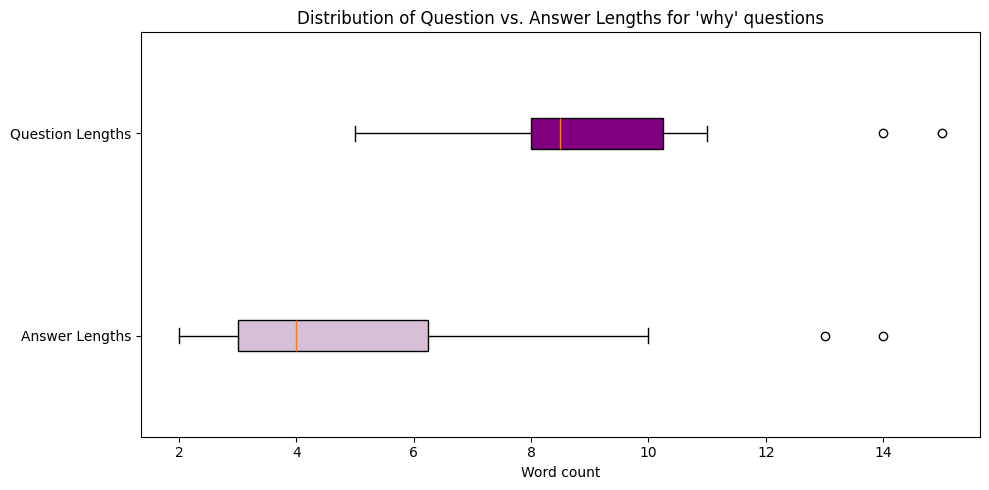

In [58]:
eda.create_ans_len_boxplot(df_for_analysis,"why")

In [59]:
eda.print_keyword_ngrams(df_for_analysis['question'],'why', (2,4),5)


Analyzing common phrases (n-grams) starting with 'why' in this set of questions:
Using stop_words: None
Top 5 common n-grams starting with 'why':
- 'why did': 6
- 'why did the': 2
- 'why did the werewolf': 2
- 'why would': 2
- 'why would you': 2


In [60]:
stop_words = ['did', 'the', 'would' ,'do', 'does']
eda.print_keyword_ngrams(df_for_analysis['question'],'why',(2,3), 3, stop_words=stop_words)


Analyzing common phrases (n-grams) starting with 'why' in this set of questions:
Using stop_words: ['did', 'the', 'would', 'do', 'does']
Top 3 common n-grams starting with 'why':
- 'why werewolf': 2
- 'why werewolf code': 2
- 'why you': 2


**Observations:"why" type questions**
- From the token count we know that there are 12 `why` type questions in the filtered dataset and the full dataset (1% of the total).
- The answers to these questions are generally long, ranging between 13 to 87 words in general.
- These questions seem more open-ended with answers that can vary for players and would require interpretation.

[[Back to TOC]](#table-of-contents)

#### 6.3.3. What do the "how" type questions look like?

In [61]:
eda.get_question_type_info(df_for_analysis,"how",n_samples)

There are 70 'how'-type questions in the data set ( 6% of total).
These questions have answers that range in lengths between 1 and 25.

Basic descriptive statistics of the answers with 'how' type questions: 
 count    70.000000
mean      3.414286
std       4.701196
min       1.000000
25%       1.000000
50%       2.000000
75%       3.750000
max      25.000000
Name: answer, dtype: float64

A random sample of the `how`- type questions: 


,question,answer,question keywords,answer keywords,combined_unique_keywords,factual_recall_keyword
679,"Before the start of his second year at Hogwarts, how do the Weasley's manage to save Harry from the Dursley's house?",With a flying car,"[dursleys, house, second, year, weasleys, harry, save, how, start, manage, hogwarts]","[fly, car]","[dursleys, house, car, second, year, weasleys, harry, save, fly, how, start, manage, hogwarts]",N/A
518,How many siblings does Ron Weasley have?,Six,"[many, ron, sibling, how, weasley]",[six],"[many, ron, six, sibling, how, weasley]",N/A
1150,How would you describe a Pixie's voice?,Shrill,"[voice, describe, how, would, pixy]",[shrill],"[voice, how, would, describe, shrill, pixy]",N/A
212,"In Harry Potter and the Prisoner of Azkaban, how do Hermione, Harry, and Ron find Crookshanks?",He jumps on Ron's head at the Magical Menagerie.,"[crookshanks, prisoner, ron, find, hermione, harry, azkaban, how, potter]","[jump, ron, menagerie, head, magical]","[crookshanks, jump, ron, prisoner, find, hermione, harry, azkaban, how, menagerie, potter, head, magical]",N/A
56,How did I become a metamorphagus?,You were born one.,"[how, become, metamorphagus]","[one, born]","[one, metamorphagus, become, born, how]",N/A
294,How do you tell if a door is Imperturbable?,Chuck stuff at it,"[door, how, imperturbable, tell]","[chuck, stuff]","[imperturbable, tell, stuff, door, chuck, how]",N/A
943,How was Hermione able to take extra lessons?,She used a time-turner,"[lesson, able, hermione, take, how, extra]","[timeturner, use]","[lesson, able, hermione, take, timeturner, how, use, extra]",N/A
40,How is Quodpot different from Quidditch?,The ball explodes,"[quidditch, how, different, quodpot]","[ball, explodes]","[explodes, ball, how, different, quidditch, quodpot]",N/A
186,How is the Grey Lady related to Rowena Ravenclaw?,She's Rowena's daughter.,"[relate, rowena, grey, how, lady, ravenclaw]","[daughter, shes, rowenas]","[relate, rowena, grey, daughter, shes, how, lady, ravenclaw, rowenas]",N/A
1125,How long should a Polyjuice Potion stew before usage?,One Month,"[polyjuice, long, potion, stew, usage, how]","[one, month]","[one, polyjuice, long, potion, stew, usage, how, month]",N/A


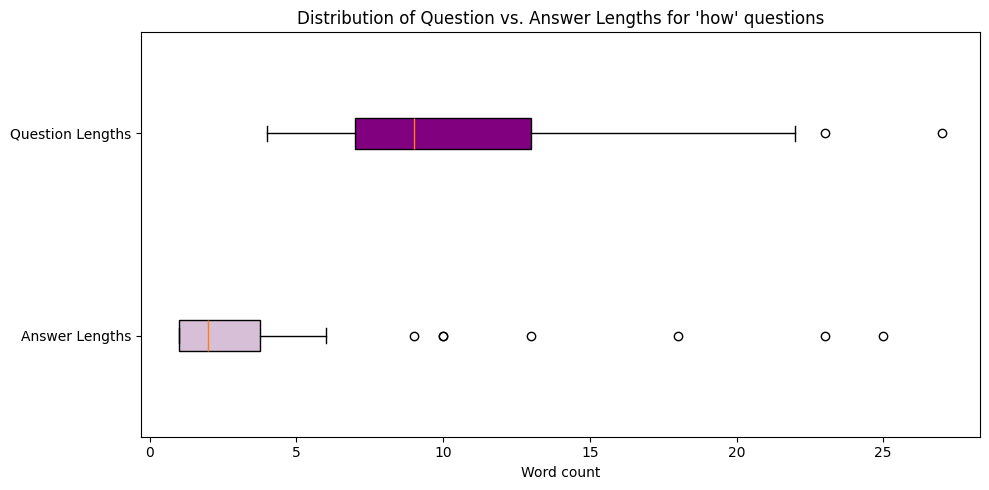

In [62]:
eda.create_ans_len_boxplot(df_for_analysis,"how")

In [63]:
eda.print_keyword_ngrams(df_for_analysis['question'],'how',(2,4))


Analyzing common phrases (n-grams) starting with 'how' in this set of questions:
Using stop_words: None
Top 10 common n-grams starting with 'how':
- 'how many': 31
- 'how do': 7
- 'how old': 6
- 'how does': 5
- 'how is': 5
- 'how did': 4
- 'how many times': 4
- 'how old was': 4
- 'how do you': 3
- 'how long': 3


**Observations: "how" type questions**: 


<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#section-63-quick-links" style="display:inline-block; padding:8px 16px; background-color:#a390d4; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to Section 6.3 Quick Links</a>

#### 6.3.4. How many questions contain multiple keywords?

In [64]:
## How many questions have multiple keywords?
condition_1 = trivia_keywords_df['factual_recall_keyword']!='N/A'
condition_2 = trivia_keywords_df['factual_recall_keyword'].str.len() > 1

filter = trivia_keywords_df[condition_1 & condition_2]
percentage = (filter['question'].count() / trivia_keywords_df.shape[0]) * 100
print(f"There are {filter.shape[0]} ({percentage: .0f}% of total) questions with multiple factual type keywords. \n")
print("Data frame preview: ")
filter.sample(20)

There are 139 ( 13% of total) questions with multiple factual type keywords. 

Data frame preview: 


,question,answer,question keywords,answer keywords,combined_unique_keywords,factual_recall_keyword
1030,What is another name for Defodio?,Gouging Spell,"[what, name, another, defodio]","[gouge, spell]","[what, defodio, gouge, name, another, spell]","[what, name]"
357,What name was Harry Potter using when he was captured at Malfoy Manor by the Death Eaters?,Vernon Dudley,"[what, capture, malfoy, death, eater, harry, name, use, potter, manor, when]","[dudley, vernon]","[what, capture, death, malfoy, eater, dudley, vernon, harry, name, use, potter, manor, when]","[what, name, when]"
425,What is the name of the ghost who haunts the Hogwarts bathroom?,Moaning Myrtle,"[what, ghost, who, haunt, name, hogwarts, bathroom]","[myrtle, moan]","[what, myrtle, ghost, who, moan, haunt, name, hogwarts, bathroom]","[what, name, who]"
123,"What is the name of the werewolf who teaches Defense Against the Dark Arts in ""Harry Potter and the Prisoner of Azkaban""?",Remus Lupin,"[what, prisoner, dark, teach, who, harry, defense, art, azkaban, name, potter, werewolf]","[remus, lupin]","[what, prisoner, lupin, dark, teach, who, harry, defense, art, azkaban, name, remus, potter, werewolf]","[what, name, who]"
922,What was the name of the person who was the original owner of the Elder Wand?,Antioch Peverell,"[what, owner, who, person, wand, elder, name, original]","[antioch, peverell]","[what, owner, who, person, wand, elder, name, antioch, original, peverell]","[what, name, who]"
837,What kind of pest repellant was Hagrid looking for when saw Harry in Knockturn Alley?,Flesh-Eating Slugs,"[what, look, kind, repellant, knockturn, harry, saw, alley, hagrid, when, pest]","[slug, flesheating]","[what, look, slug, repellant, knockturn, harry, saw, alley, flesheating, hagrid, pest, when, kind]","[what, when]"
498,What is the name of the Hogwarts poltergeist?,Peeves,"[hogwarts, what, poltergeist, name]",[peeve],"[what, peeve, name, poltergeist, hogwarts]","[what, name]"
483,What other name is the Doxy commonly known by?,The Biting Fairy.,"[what, commonly, know, doxy, name]","[fairy, bite]","[what, bite, fairy, commonly, know, doxy, name]","[what, name]"
1014,Who is the Headmaster of Hogwarts when Harry arrives?,Albus Dumbledore.,"[arrive, harry, who, headmaster, hogwarts, when]","[albus, dumbledore]","[arrive, harry, who, dumbledore, albus, headmaster, hogwarts, when]","[who, when]"
1187,What is the full name of Nearly Headless Nick?,Sir Nicholas de Mimsy-Porpington,"[what, full, headless, nick, nearly, name]","[nicholas, de, sir, mimsyporpington]","[what, full, mimsyporpington, sir, headless, de, nick, nearly, name, nicholas]","[what, name]"


Not surprising that 'what' and 'name' appear together several times, with 'where' popping up too — so there's some overlap between these keywords. However, in these overlapping cases, the question always starts with 'what' — the dominant keyword.

It's fairly clear that the majority of questions in this dataset are factual recall (74%), and among those, what questions (49%) related to objects, events, facts, and character names are the most common.

>**NOTE**:
>A second pass that includes combinations of two or more keywords would be useful. Considering counts without overlap?
<br>

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#section-63-quick-links" style="display:inline-block; padding:8px 16px; background-color:#a390d4; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to Section 6.3 Quick Links</a>

#### 6.3.5 What do the remaining 'N/A' questions look like?

We will use the `q_filter_df` because this dataframe only contain the questions that were tagged as 'N/A' in the 'factual_recall_keywords' column. Here we only want columns that do not have `which` or `why` as a keyword.

In [65]:
# Filter condition:
remaining_na_condition = q_filtered_df['question keywords'].apply(
    lambda x: all(word not in x for word in ['why', 'which','how'])
)
remaining_na_questions_df = q_filtered_df.loc[remaining_na_condition]

# Display results
print("Number of questions that are not 'which' or 'why' type but tagged as 'N/A': ", remaining_na_questions_df.shape[0])
print("Sample of questions: \n")
remaining_na_questions_df

Number of questions that are not 'which' or 'why' type but tagged as 'N/A':  23
Sample of questions: 



,question,answer,question keywords,answer keywords,combined_unique_keywords,factual_recall_keyword
28,"""Lemon Drop"" is the password to whose office?",Dumbledore,"[drop, office, lemon, password, whose]",[dumbledore],"[drop, office, dumbledore, lemon, password, whose]",N/A
108,Did Muggles use ancient runes as well?,They did.,"[well, ancient, muggles, rune, use]",[],"[well, muggles, ancient, rune, use]",N/A
147,"On his first ride aboard the Hogwarts Express, whose card did Harry get with his chocolate frog?",Dumbledore,"[aboard, frog, first, ride, get, harry, card, express, chocolate, hogwarts, whose]",[dumbledore],"[aboard, frog, first, ride, get, harry, card, dumbledore, express, chocolate, hogwarts, whose]",N/A
389,True or false: Harry Potter and the Deathly Hallows: Part Two is the shortest Harry Potter movie.,True! The run time is just 130 minutes.,"[hallows, harry, two, true, deathly, false, shortest, potter, movie, part]","[time, true, minute, run]","[run, hallows, time, minute, harry, two, true, deathly, false, shortest, potter, movie, part]",N/A
419,Where's one place you would not find any gnomes?,Antarctica,"[one, place, gnome, find, wheres, would]",[antarctica],"[one, place, gnome, find, antarctica, wheres, would]",N/A
544,Fill in the blank: Petrificus Totalus is the incantation for the Full Body-Bind curse.,Bind (Got this in the Petrificus Totalus lesson.),"[blank, curse, full, fill, petrificus, bodybind, incantation, totalus]","[lesson, petrificus, get, totalus, bind]","[blank, curse, full, fill, petrificus, lesson, bodybind, incantation, get, totalus, bind]",N/A
601,True or false: This is the longest movie in the franchise.,"False! Harry Potter and the Chamber of Secrets is the longest movie, at 161 minutes.","[long, true, false, movie, franchise]","[minute, harry, chamber, false, potter, movie, secret, longest]","[long, minute, harry, chamber, true, secret, false, potter, movie, franchise, longest]",N/A
636,Wich of these creatures is notable proud and easy to offend if not treated politely?,Hippogriff,"[treat, offend, notable, politely, creature, easy, proud, wich]",[hippogriff],"[treat, offend, politely, notable, creature, easy, proud, hippogriff, wich]",N/A
667,The Bouncy Bulb is extremely difficult to...,Pot.,"[extremely, bulb, bouncy, difficult]",[pot],"[bulb, bouncy, extremely, difficult, pot]",N/A
681,"Whose teeth did Nearly Headless Nick accidentally turn into tusks, leading to his death?",Lady Grieve,"[turn, death, accidentally, lead, headless, nick, tusk, teeth, nearly, whose]","[lady, grieve]","[death, turn, accidentally, lead, headless, grieve, nick, tusk, teeth, nearly, lady, whose]",N/A



##### What are the remaining questions like?

- The use other keywords such as 'whose', 'can', 'did', 'does', 'do' , 'is it',  'wheres', 'whom' (variation not caught in list). Some of these words can be added to the list e.g. "whom", "wheres", "whose" but the other words are very ambiguous and may introduce noise in the keywords.
- indicative statements instead of questions - e.g. "Dittany, mixed with this ingredient, can cure a Werewolf bite." Ans: "Powdered Silver"
- nonsensical questions (not for trivia), e.g. Q: "Will you serve the great nation of Peevesland, soldier?", Ans: "Sir, yes, sir!"
- 2x True / false type.
- 1x fill-in-the-blank, e.g. Q:"Fill in the blank: Petrificus Totalus is the incantation for the Full Body-Bind curse." Ans: "Bind (Got this in the Petrificus Totalus lesson.)" <- thre is an error here though - no blank given in the question and it is very unclear what is being asked.
x

##### What can we do with these remaining questions?

There are now only 23 questions that have a 'N/A' questions. 
Should these questions be modified so one of the `factual_recall_keywords` can be applied?  This would mean changing the question wording to lead with an appropriate `factual_recall_keyword` where possible. But that would reduce variety and nuance in the dataset even if, right now, these type are only a small percentage of the questions. This also makes the analysis / game more flexible towards expanding the trivia Q&A dataset in future project phases.


> NOTES: 
>- some questions are fill-in-the blanks (e.g q id 667: "The Bouncy Bulb is extremely difficult to ...")
>- others are random "fun" questions? e.g. (Q1271. "Will you serve the great nation of Peevesland, soldier?" - Ans: 'Sir, yes, sir!')
>- presented as statements (Q929: "Dittany, mixed with this ingredient, can cure a Werewolf bite.", Ans: "Powdered Silver")
>- Q.644 "Why did the Werewolf Code of Conduct fail?" and Q.1228 appear to be duplicates.

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#section-63-quick-links" style="display:inline-block; padding:8px 16px; background-color:#a390d4; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to Section 6.3 Quick Links</a>

#### 6.3.6 Plan of Action

**Decision**: will not modify questions instead add additional keyword columns for other types of questions (open-ended, yes/no etc). 
    
So the **plan of action** is:

1. Filter/Remove: Identify and remove/flag 'Nonsensical' and known 'Problematic' (like the bad fill-in-the-blank and only one of its type) questions first.
2. Classify Yes/No: Check if the first word of the question is in your yes_no_keywords list. Tag as Yes/No.
3. Classify True/False: Check if answer text is 'True'/'False'. Also tag this as a Yes/No type.
4. Classify Factual Recall: Expand the factual_recall_keywords list and use it for tagging the dataset again (including what, who, where, when, which, whose, whom, wheres, name, how many etc.). Tag with Factual keyword.
5. Classify open-ended: Check if the first word is 'Why' or potentially 'How'<pending>. Tag as Explanatory.
6. Recheck remainder manually after tagging and decide what to do (tag unassigned? keep it flexible for future addition that way?
7. Determine the logic for then categorizing the questions using binary tag columns for each question type. Clarify logic for assigning tag. How will conflicts be handled when there are tags present from multiple question type categories? --> consider hierarchical, rule based approach.
8. With the addition of new columns, create a data dictionary of the finalized dataframe. Create the final data save checkpoint for the game version dataset to be used in the CLI MVP. Also create an accompanying data dictionary json file for the csv.

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#section-63-quick-links" style="display:inline-block; padding:8px 16px; background-color:#a390d4; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to Section 6.3 Quick Links</a>

### 6.4 Common N-grams in the dataset

In [66]:
eda.print_common_ngrams(df_for_analysis['question'],(2,4), top_n=20)


Analyzing common phrases (n-grams) in this set of questions:
Top 20 common n-grams:
- 'harry potter': 48
- 'does harry': 17
- 'sorcerer stone': 13
- 'ministry magic': 12
- 'magical creature': 11
- 'triwizard tournament': 11
- 'quidditch team': 10
- 'did harry': 9
- 'draco malfoy': 9
- 'harry potter series': 9
- 'potter series': 9
- 'chamber secrets': 8
- 'common room': 8
- 'did hermione': 8
- 'professor snape': 8
- 'harry ron': 7
- 'hermione granger': 7
- 'polyjuice potion': 7
- 'does hermione': 6
- 'fred george': 6


In [67]:
eda.print_common_ngrams(df_for_analysis['answer'],(2,4), top_n=20)


Analyzing common phrases (n-grams) in this set of questions:
Top 20 common n-grams:
- 'bloody baron': 8
- 'ministry magic': 6
- 'moaning myrtle': 6
- 'severus snape': 6
- 'sirius black': 6
- 'armando dippet': 5
- 'hermione granger': 5
- 'albus dumbledore': 4
- 'gilderoy lockhart': 4
- 'harry potter': 4
- 'horace slughorn': 4
- 'mimsy porpington': 4
- 'nicholas mimsy': 4
- 'nicholas mimsy porpington': 4
- 'patronus charm': 4
- 'wizard wheezes': 4
- '10th century': 3
- 'cho chang': 3
- 'chudley cannons': 3
- 'daily prophet': 3


<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>

## 7. Extending the dataset with new question categorization columns

## 7.1. Dataset cleaning based on findings from in-depth EDA

**Task list:**
1. Delete Q.(1271. Q:"Will you serve the great nation of Peevesland, soldier?" - A:"Sir, yes, sir!")
2. Delete duplicate (Q. 644 & 1228 are identical and missed in earlier cleaning).
3. Edit Q. 667 (Fill in the blank: Petrificus Totalus is the incantation for the Full Body-Bind curse.) -> no missing blanks, (A: Bind (Got this in the Petrificus Totalus lesson.)) --> change to [Q: "Fill in the blank: Petrificus Totalus is the incantation for the full ____-_____ curse." / A:"Body-bind"]
4. Q.230 looks incomplete - need to have a look at question before or after in case if it was somehow split across rows?

In [68]:
## Updated keyword lists for searching different types of questions.

# Factual recall: expanded list of words to look for when identifying 'factual recall' questions 
expanded_factual_recall_list = ['what', 'name', 'who', 'where', 'wheres', 'when', 'whats', 'whose']

# Open-ended: new list
open_ended_list = ['why', 'how']

# Yes/No: new list
# in questions: 
yesno_question_start_keywords = ['is', 'are', 'was', 'were', 'do', 'does', 'did', 'can', 'could', 'has', 'had', 'will', 'would', 'should','True', 'False'] # in question
# validation check with answers
yesorno_list_forans = ['True', 'False', 'Yes', 'No'] # in answer

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>

## 8. Summary

Answer lengths:
- Majority of the answers are 

- Signifiant analysis and categorization of the questions types was achieved just by tokenizing the question and answers and looking at the question syntax. The trivia dataset follows question pattern of what can typically be expected and could be categorized into question types.
- The vast majority of the questions are factual-recall type (97%).  The answers to factual-recall type questions are relatively simpler to analyze for correctness.
- Of the 97%, majority (49%) of the factual-recall types use 'what' as a keyword to pharse the question. 
- There are other question formats in the dataset as well:
    - True / False or Yes / No -> binary choice
    - Fill in the blank
    - open-ended or explanatory
    - question written as statements
- There were no multiple-choice questions.
- There were also spelling mistakes and problematic (nonsensical) questions that needed to be cleaned. 
- A design decision was made not to modify or remove the uncategorized questions.
- The dataset right now is sufficient for the CLI-MVP.
- However, the data analysis so far has not taken into account 'Harry Potter' specific content. This will be tackled specifically in the next project phase using custom NER classes.

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>

## 9. Key findings

1. 97%+ successful categorization even before NER work - excellent success metric.
2. Similar contextual, "Harry Potter" centric categorization will help enrich the game experience and help make it more immersive.
2. The main distinguishing factor for questions in the dataset is whether they are 'factual-recall' type or not. These question types generally have straight forward answers. Answer comparison with user input should be relatively straight forward for the MVP.
4. When growing the dataset for next phases 
    - can balance the other question type categories (especially open-ended, nuanced questions to make NLP features shine)
    - add multiple choice questions especially for easy mode
    - Can also balance the categories within the 'factual-recall' - this will help with medium / difficult levels.

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>

<div align="center" style="background-color: #f0e6f7; padding: 10px;">
    <span style="color:purple; font-size:32px;">Part-4: Finalizing dataset for CLI-MVP</span>
</div>

## 10. Data dictionary

1. Data dictionary table
2. Json conversion for the csv

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>

## 11. Next steps

Based on the work completed in this notebook:

1. **CLI MVP Input:** <br>
The dataset generated here, containing the cleaned trivia questions/answers and extracted keywords (from the second checkpoint), serves as the primary data source for the current command-line interface (CLI) MVP of the trivia game. 

2.  **Further Feature Enhancement (NER):**<br>
 The next phase of data enrichment involves applying Named Entity Recognition (NER) to potentially classify questions or extract structured information like difficulty and category. This work is planned for the [NER Implementation notebook](03-NER_implementation.ipynb)

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>

---

#### 💾 Checkpoint 3: Phase-1 CLI-MVP dataset 

Saving clean dataset with keywords and question type tags
<details>
<summary> Click here for checkpoint details and <b>warning!</b> </summary>

The DataFrame is now cleaned, EDA completed, with the keywords and question-type features columns. Saving the current state.
<br>
> **⚠️ Caution: Manual Intervention Required for Saving Files**
>
> Please be aware that the `save_dataframe_to_csv` utility is designed to prevent accidental data loss. It **does not automatically overwrite** previously saved files.
>
> If you run a cell that calls this function and the output file (based on `filename_base`, `version`, and `subfolder`) already exists, the save operation will be skipped. You will see a message indicating this.
>
> **To save your latest data, you must manually intervene by either:**
> 1.  Deleting the older version of the CSV file from the file system.
> 2.  Modifying the `version` argument (or `filename_base`) in your function call to create a new, unique filename.

The following code saves the cleaned DataFrame to <code>data/project_datasets/</code> based on the selected `Save arguments` in the code below.
</div>
</details>

In [69]:
# Using utils.paths.py module -> prevents overwritting csv file unless manually done.

# Save arguments
# dataframe_to_save = 
name_for_csvfile = 'CLI-MVP_trivia_dataset'
csv_version = 'v0'
csv_subfolder = 'project_datasets'

# Save csv  file with custom functions and defined save arguments
# up.save_dataframe_to_csv(dataframe_to_save, name_for_csvfile, csv_version, csv_subfolder)

---

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#1-introduction" style="display:inline-block; padding:8px 16px; background-color:#a390d4; color:white; text-align:center; text-decoration:none; border-radius:4px;">Return to the Top</a>